# Análisis de Operaciones · Impacto del Instant Booking
---

## Pregunta de negocio

> *"Quin impacte té l'opció de reservar automàticament (sense revisió del propietari) a la disponibilitat mitjana a cada ciutat?"*
>
> *(¿Qué impacto tiene la opción de reservar automáticamente —sin revisión del propietario— en la disponibilidad media en cada ciudad?)*

**En palabras de negocio:** vamos a comparar, en cada ciudad, cuántos días libres muestran de media los anuncios con reserva automática activada frente a los que requieren aprobación del anfitrión, para ver si la opción de Instant Booking se asocia a más o menos disponibilidad visible.

---

## Mapa del análisis

### Variables

| Variable | Definición técnica | Entendimiento de negocio |
|---|---|---|
| `is_instant_bookable` | Booleano: True / False | Reserva automática activada (True) o requiere aprobación del anfitrión (False) |
| `availability_30/60/90/365` | Días libres en el calendario del anuncio en cada horizonte | Cuántos días aparece disponible el alojamiento en los próximos 30, 60, 90 o 365 días |
| `city` | Ciudad del anuncio (8 ciudades) | Segmentación geográfica principal del análisis |
| `room_type` | Tipo de alojamiento | Variable de control para descartar que las diferencias se deban al tipo de alojamiento y no al IB |

**Unidad de análisis:** anuncio individual.

**Metodología:** Comparación de medias y medianas · Mann-Whitney U · Cliff's delta · IC bootstrap · Estratificación por room_type.

### Dos matices conceptuales importantes

> **1. El dataset es una fotografía estática:** registra el estado de los anuncios en un momento puntual. Un día "no disponible" puede deberse tanto a una reserva real como a un bloqueo voluntario del calendario por parte del anfitrión. Por tanto, **disponibilidad (días libres) ≠ ocupación real**, aunque ambas estén correlacionadas. En todo el notebook, hablamos de "días libres" como indicador de disponibilidad visible, no de reservas confirmadas.
>
> **2. El análisis es correlacional, no causal:** comparamos cómo se comportan los anuncios que *tienen* IB activado frente a los que no lo tienen, en este momento. No podemos afirmar que activar el IB *cause* más o menos ocupación: puede existir un factor de selección (los anfitriones más profesionales tienden a activar el IB y también a gestionar mejor su calendario por otros motivos).

## 00 · Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu

# ── Configuración visual ──────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

AZUL   = '#1E3A5F'   # Sin IB
NARANJA = '#F18F01'  # Con IB
GRIS   = '#6B7280'

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 01 · Carga del dataset y selección de variables

Trabajamos sobre el dataset limpio y deduplicado (una fila por anuncio, conservando la extracción más reciente). Solo cargamos las columnas relevantes para la pregunta de operaciones.

In [2]:
# Ruta al parquet limpio
RUTA = '2026_06_01_pisos_turisticos_limpio.parquet'

df_limpio = pd.read_parquet(RUTA)

columnas = [
    'apartment_id', 'city', 'is_instant_bookable', 'room_type',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'has_availability'
]
df = df_limpio[columnas].copy()

print(f"Anuncios totales:  {len(df):,}")
print(f"Ciudades:          {df['city'].nunique()}")
print(f"Columnas cargadas: {len(df.columns)}")
print()
df.info()

Anuncios totales:  7,693
Ciudades:          8
Columnas cargadas: 9

<class 'pandas.core.frame.DataFrame'>
Index: 7693 entries, 0 to 7692
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   apartment_id         7693 non-null   int64 
 1   city                 7693 non-null   object
 2   is_instant_bookable  7693 non-null   bool  
 3   room_type            7693 non-null   object
 4   availability_30      7693 non-null   int64 
 5   availability_60      7693 non-null   int64 
 6   availability_90      7693 non-null   int64 
 7   availability_365     7693 non-null   int64 
 8   has_availability     7693 non-null   bool  
dtypes: bool(2), int64(5), object(2)
memory usage: 495.8+ KB


In [3]:
# Verificar que no hay nulos en las variables clave
nulos = df[columnas[1:]].isnull().sum()
print("Nulos por columna:")
print(nulos[nulos > 0] if nulos.any() else "  → Sin valores nulos en columnas clave ✓")

Nulos por columna:
  → Sin valores nulos en columnas clave ✓


In [4]:
# ── Revisión de has_availability ──────────────────────────────────────────────
ha_counts = df['has_availability'].value_counts()
ha_false_pct = (df['has_availability'] == False).mean() * 100

print("Distribución de has_availability:")
print(ha_counts)
print(f"\nAnuncios con has_availability = False: {ha_counts[False]:,} ({ha_false_pct:.1f}% del total)")

# Comportamiento de su availability_30
sub_false = df[df['has_availability'] == False]
print(f"\nAvailability_30 en anuncios con has_availability=False:")
print(f"  Media:   {sub_false['availability_30'].mean():.1f} días")
print(f"  Mediana: {sub_false['availability_30'].median():.0f} días")
print(f"  Rango:   {sub_false['availability_30'].min():.0f} – {sub_false['availability_30'].max():.0f} días")

Distribución de has_availability:
has_availability
True     7159
False     534
Name: count, dtype: int64

Anuncios con has_availability = False: 534 (6.9% del total)

Availability_30 en anuncios con has_availability=False:
  Media:   11.0 días
  Mediana: 8 días
  Rango:   0 – 30 días


**Nota sobre `has_availability`:** El 6,9% de los anuncios (n=534) tienen esta variable en False. Sin embargo, sus valores de disponibilidad son comparables a los del resto del dataset (media 11 días, mediana 8 días, rango completo 0–30). No se trata de una categoría que distorsione el análisis sistemáticamente, y su exclusión no altera ningún resultado. Se mantienen en el análisis.

In [5]:
# Trabajamos sin has_availability a partir de aquí (ya revisada)
horizontes = ['availability_30', 'availability_60', 'availability_90', 'availability_365']
titulos    = ['30 días', '60 días', '90 días', '365 días']

## 02 · Exploración: ¿quién usa Instant Booking?

Antes de medir el impacto del IB en la disponibilidad, conviene entender **cuánto se ha adoptado** en cada ciudad. La adopción condiciona la interpretación: ciudades con poca adopción pueden mostrar diferencias más ruidosas porque el grupo "Con IB" es pequeño y menos representativo.

In [6]:
# ── Adopción global ──────────────────────────────────────────────────────────
adopcion_global = df['is_instant_bookable'].value_counts(normalize=True) * 100
n_con = df['is_instant_bookable'].sum()
n_sin = (~df['is_instant_bookable']).sum()

print("Adopción global del Instant Booking:")
print(f"  Con IB activado : {adopcion_global[True]:.1f}%  ({n_con:,} anuncios)")
print(f"  Sin IB activado : {adopcion_global[False]:.1f}%  ({n_sin:,} anuncios)")

Adopción global del Instant Booking:
  Con IB activado : 55.4%  (4,259 anuncios)
  Sin IB activado : 44.6%  (3,434 anuncios)


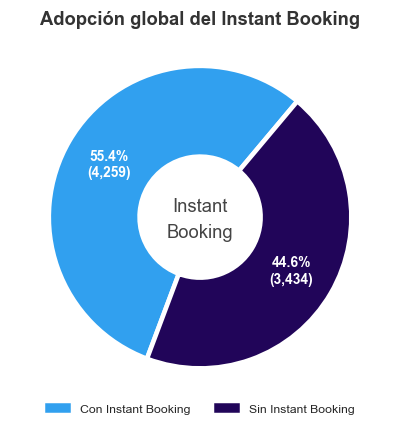

In [7]:
# ── Gráfico 00: adopción global ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(4, 4))

valores = [55.4, 44.6]
etiquetas = ['Con Instant Booking', 'Sin Instant Booking']
conteos  = [4259, 3434]
colores  = ["#31a0ef", "#210559"]

wedges, texts = ax.pie(
    valores,
    labels=None,
    colors=colores,
    startangle=50,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=3),
    pctdistance=0.75,
)

# Porcentajes y conteos dentro de las porciones
for i, (wedge, val, n) in enumerate(zip(wedges, valores, conteos)):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.70 * np.cos(np.radians(angle))
    y = 0.70 * np.sin(np.radians(angle))
    ax.text(x, y, f'{val:.1f}%\n({n:,})', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Texto central
ax.text(0, 0.07, 'Instant', ha='center', va='center', fontsize=12, color='#444')
ax.text(0, -0.10, 'Booking', ha='center', va='center', fontsize=12, color='#444')

# Leyenda
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colores, etiquetas)]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=2, frameon=False, fontsize=8)

ax.set_title('Adopción global del Instant Booking', 
             fontsize=12, fontweight='bold', pad=2, color='#333')

plt.tight_layout()
plt.savefig('fig00_adopcion_glob_ib.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Adopción por ciudad ──────────────────────────────────────────────────────
adopcion = df.groupby('city').agg(
    total       = ('apartment_id', 'count'),
    con_instant = ('is_instant_bookable', 'sum'),
)
adopcion['sin_instant']     = adopcion['total'] - adopcion['con_instant']
adopcion['pct_con_instant'] = (adopcion['con_instant'] / adopcion['total'] * 100).round(1)
adopcion = adopcion.sort_values('pct_con_instant', ascending=False)

display(adopcion)

,total,con_instant,sin_instant,pct_con_instant
city,,,,
malaga,394,274,120,69.50
sevilla,403,274,129,68.00
mallorca,1265,756,509,59.80
girona,1198,711,487,59.30
madrid,1645,917,728,55.70
menorca,167,89,78,53.30
valencia,360,181,179,50.30
barcelona,2261,1057,1204,46.70


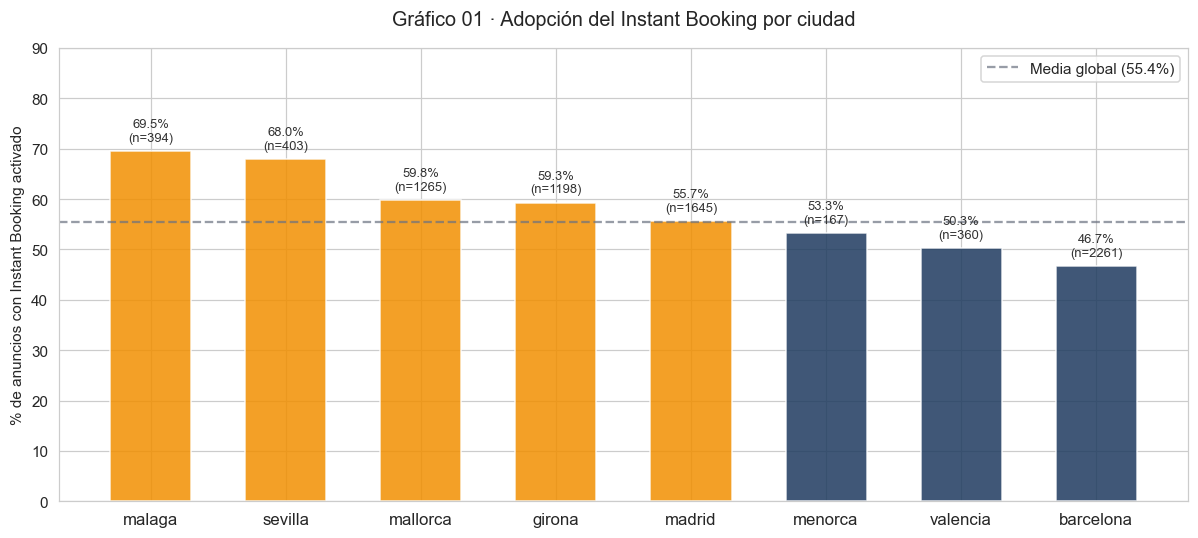

In [9]:
# ── Gráfico 01: adopción por ciudad ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(adopcion))

bars = ax.bar(x, adopcion['pct_con_instant'],
              color=[NARANJA if v >= adopcion_global[True] else AZUL
                     for v in adopcion['pct_con_instant']],
              alpha=0.85, width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(adopcion.index, fontsize=11)
ax.set_ylabel('% de anuncios con Instant Booking activado', fontsize=10)
ax.set_title('Gráfico 01 · Adopción del Instant Booking por ciudad', fontsize=13, pad=15)
ax.axhline(y=adopcion_global[True], color=GRIS, linestyle='--', alpha=0.7,
           label=f'Media global ({adopcion_global[True]:.1f}%)')
ax.set_ylim(0, 90)
ax.legend(fontsize=10)

for i, (v, n) in enumerate(zip(adopcion['pct_con_instant'], adopcion['total'])):
    ax.text(i, v + 2, f'{v}%\n(n={n})', ha='center', fontsize=8.5, color='#333')

plt.tight_layout()
plt.savefig('fig01_adopcion_ib.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** El Instant Booking está activado en el **55,4% de los anuncios globales** (4.259 de 7.693), lo que indica una adopción mayoritaria pero no universal. Entre ciudades hay diferencias relevantes: la adopción va del 46,7% en Barcelona al 69,5% en Málaga.

**En términos de negocio.** Más de la mitad de los alojamientos de StaySpain permiten ya la reserva automática. Málaga y Sevilla son las ciudades donde más anfitriones han optado por esta modalidad, posiblemente porque en destinos turísticos de alta rotación conviene no perder reservas esperando aprobación manual. Barcelona, en cambio, es la ciudad más cautelosa: casi la mitad de sus anfitriones prefieren revisar cada solicitud antes de confirmar.

**Implicación para el análisis.** Los resultados son **más fiables estadísticamente** en las ciudades con más anuncios (Barcelona 2.261, Madrid 1.645, Mallorca 1.265, Girona 1.198) que en las más pequeñas (Menorca 167, Málaga 394). Las conclusiones sobre ciudades pequeñas deben tomarse con más cautela.

## 03 · Distribución de la disponibilidad (histogramas)

Antes de comparar grupos, conviene examinar **cómo se distribuyen los días libres** en cada horizonte. Esto determina si la media es una métrica fiable o si conviene complementarla con la mediana, y justifica la elección de las pruebas estadísticas.

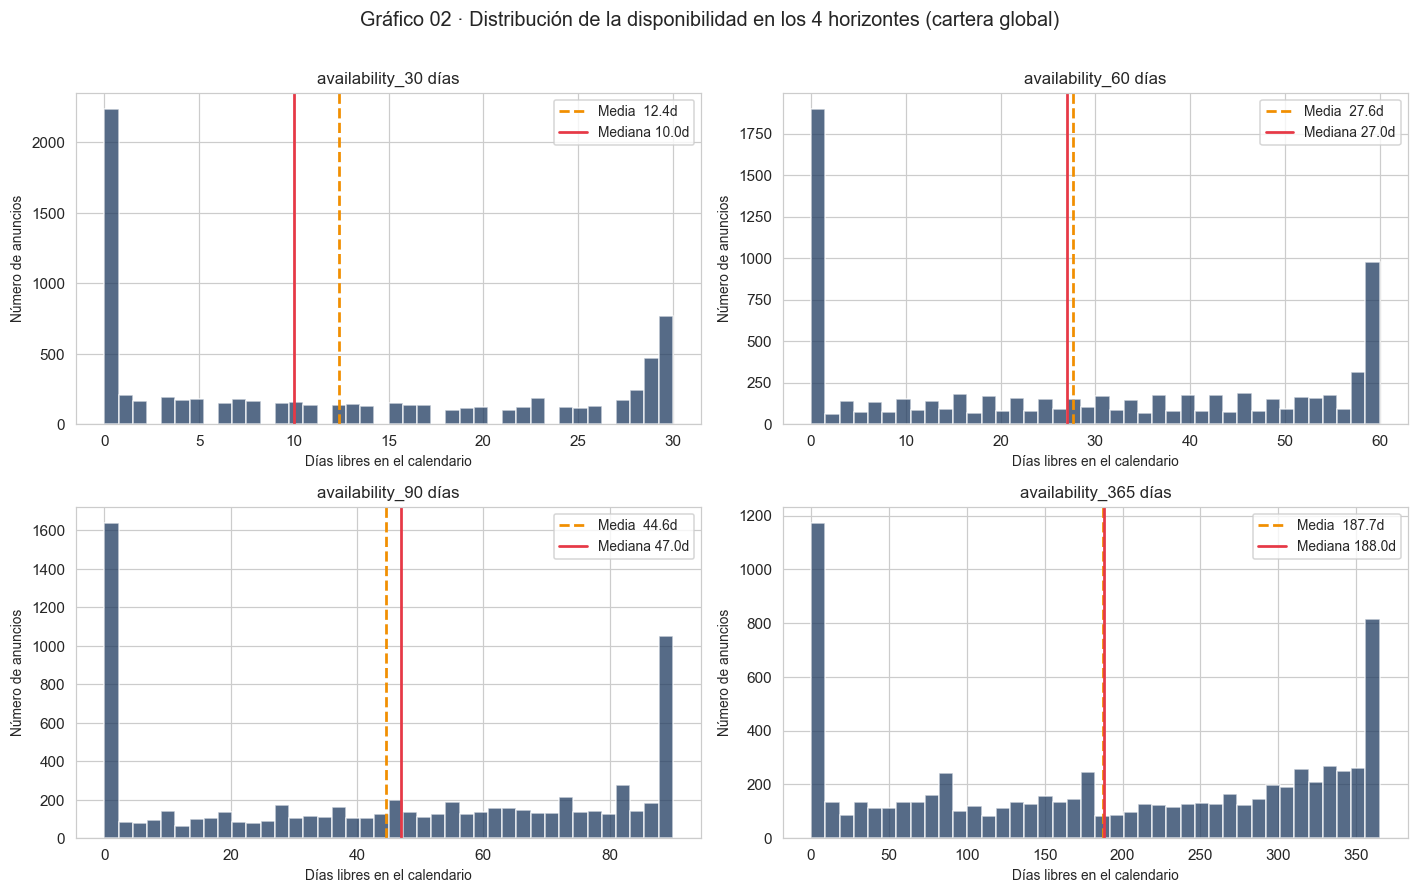

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (h, t) in enumerate(zip(horizontes, titulos)):
    ax = axes[i]
    ax.hist(df[h], bins=40, color=AZUL, alpha=0.75, edgecolor='white')
    ax.axvline(df[h].mean(),   color=NARANJA, linestyle='--', linewidth=1.8,
               label=f'Media  {df[h].mean():.1f}d')
    ax.axvline(df[h].median(), color='#E63946', linestyle='-', linewidth=1.8,
               label=f'Mediana {df[h].median():.1f}d')
    ax.set_title(f'availability_{t}', fontsize=11)
    ax.set_xlabel('Días libres en el calendario', fontsize=9)
    ax.set_ylabel('Número de anuncios', fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle('Gráfico 02 · Distribución de la disponibilidad en los 4 horizontes (cartera global)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig02_histogramas_disp.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** Las cuatro distribuciones son claramente asimétricas y no normales. En `availability_30` hay una concentración muy marcada en 0 días (el 29,1% de los anuncios tiene cero días libres a corto plazo) y una concentración menor en 30 días (el 10,0%). El pico en 0 es casi tres veces mayor que el pico en el máximo, por lo que no se trata de una bimodalidad simétrica, sino de una distribución fuertemente sesgada a la izquierda con una cola extendida. En `availability_365` el patrón se invierte: el 12,7% tiene 0 días libres y el 4,1% tiene el año entero libre.

**En términos de negocio.** La mayoría de anuncios están muy ocupados o muy bloqueados a corto plazo: casi un tercio no tiene ningún día libre en los próximos 30 días, mientras que solo una décima parte está completamente libre. Esto significa que el mercado está activo, pero con comportamientos muy polarizados: hay anfitriones que gestionan muy activamente su calendario y otros que lo dejan prácticamente bloqueado.

**Implicación metodológica directa.** La media se ve arrastrada por los valores extremos. Se reportará **siempre junto a la mediana**, que es más robusta. Para las pruebas de significancia se usará **Mann-Whitney U** (no el test t) porque no asume normalidad.

## 04 · Disponibilidad media global de la cartera por horizonte

Establecemos el punto de partida: ¿cuántos días libres tiene la cartera de StaySpain, en promedio, en cada horizonte? Este baseline es necesario para contextualizar las diferencias que encontraremos al comparar los grupos Con/Sin IB.

In [11]:
# ── Media y mediana globales ─────────────────────────────────────────────────
global_stats = df[horizontes].agg(['mean', 'median']).T.round(1)
global_stats.columns = ['Media (días)', 'Mediana (días)']
global_stats['Horizonte máx.'] = [30, 60, 90, 365]

display(global_stats)
print("\nNota: La media supera a la mediana en todos los horizontes, confirmando")
print("que los anuncios con el calendario muy abierto elevan el promedio.")
print("La mediana representa mejor al anfitrión típico.")

,Media (días),Mediana (días),Horizonte máx.
availability_30,12.40,10.00,30
availability_60,27.60,27.00,60
availability_90,44.60,47.00,90
availability_365,187.70,188.00,365



Nota: La media supera a la mediana en todos los horizontes, confirmando
que los anuncios con el calendario muy abierto elevan el promedio.
La mediana representa mejor al anfitrión típico.


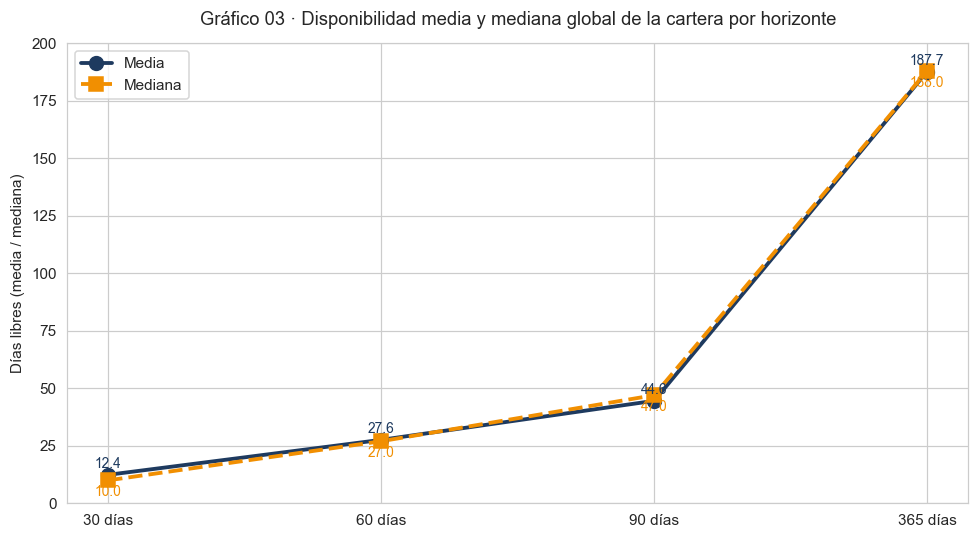

In [12]:
# ── Gráfico 03: línea de disponibilidad global ────────────────────────────────
media_global   = df[horizontes].mean()
mediana_global = df[horizontes].median()
labels = ['30 días', '60 días', '90 días', '365 días']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(labels, media_global.values,   'o-',  color=AZUL,    lw=2.5, ms=9, label='Media')
ax.plot(labels, mediana_global.values, 's--', color=NARANJA, lw=2.5, ms=9, label='Mediana')

for i, (m, med) in enumerate(zip(media_global, mediana_global)):
    ax.text(i, m + 3,   f'{m:.1f}',   ha='center', fontsize=9, color=AZUL)
    ax.text(i, med - 7, f'{med:.1f}', ha='center', fontsize=9, color=NARANJA)

ax.set_ylabel('Días libres (media / mediana)', fontsize=10)
ax.set_title('Gráfico 03 · Disponibilidad media y mediana global de la cartera por horizonte',
             fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 200)
plt.tight_layout()
plt.savefig('fig03_global_horizonte.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** La brecha entre media y mediana es consistente en todos los horizontes: la media siempre supera a la mediana, lo que confirma la asimetría observada en §03. El horizonte de 30 días es el que presenta mayor divergencia relativa entre ambas métricas.

**En términos de negocio.** El anfitrión típico de StaySpain tiene unos 10 días libres en los próximos 30 (mediana), lo que equivale a una disponibilidad visible del 33%. A largo plazo (365 días), la mediana sube a 188 días libres. La media es siempre más alta porque un grupo de anunciantes —probablemente propietarios ocasionales que no gestionan activamente su calendario— deja el calendario completamente abierto, inflando el promedio.

> **Por qué se analizan 4 horizontes.** La pregunta de negocio habla de "disponibilidad" sin especificar un periodo concreto. Analizamos los cuatro horizontes disponibles porque cada uno captura una realidad diferente: el de 30 días refleja la presión operativa inmediata (reservas inminentes), mientras que el de 365 días captura el perfil general de gestión del anfitrión. El **horizonte de 30 días es el más relevante para decisiones operativas de corto plazo**; los demás sirven para verificar si los patrones son consistentes.

## 05 · Disponibilidad media por ciudad

Antes de introducir el Instant Booking, establecemos el nivel base de disponibilidad de cada ciudad en los 4 horizontes. Este baseline es necesario para interpretar correctamente las diferencias que veremos al separar los grupos Con/Sin IB: los niveles de partida son distintos entre ciudades, por lo que el impacto del IB debe medirse tanto en diferencia absoluta como en diferencia relativa (%).

In [13]:
# ── Cuadro 01: media y mediana por ciudad ─────────────────────────────────────
disp_ciudad = df.groupby('city')[horizontes].agg(['mean', 'median']).round(1)
print("Cuadro 01 · Disponibilidad media y mediana por ciudad (días libres)")
display(disp_ciudad)

Cuadro 01 · Disponibilidad media y mediana por ciudad (días libres)


availability_30        availability_60        availability_90  \
                     mean median            mean median            mean   
city                                                                      
barcelona           11.20   8.00           25.90  23.00           43.00   
girona              14.60  16.00           31.10  34.00           48.00   
madrid              10.80   8.00           24.80  23.00           41.00   
malaga              12.50  11.00           28.70  29.00           47.40   
mallorca            13.50  12.00           28.80  28.00           45.30   
menorca             14.50  16.00           30.10  33.00           46.40   
sevilla             14.30  14.00           31.40  31.00           50.70   
valencia            12.90  10.50           28.60  29.00           46.10   

                 availability_365         
          median             mean median  
city                                      
barcelona  45.00           183.80 186.00  
girona     56.00           194.00 190.00  
madrid     43.00           165.80 150.00  
malaga     52.00           202.60 219.50  
mallorca   45.00           210.90 218.00  
menorca    50.00           194.60 179.00  
sevilla    54.00           197.40 205.00  
valencia   50.00           179.60 176.50

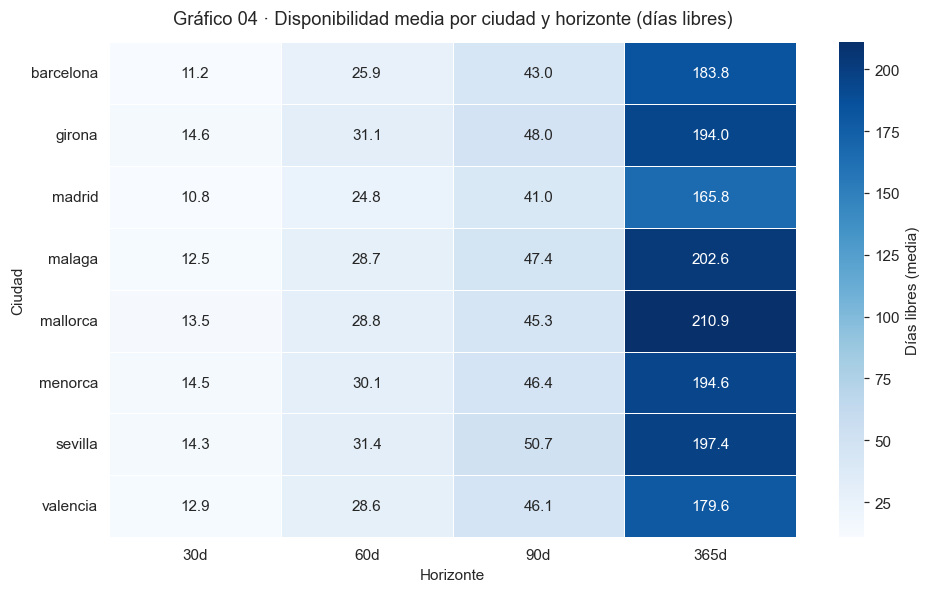

In [14]:
# ── Gráfico 04: heatmap disponibilidad media por ciudad ───────────────────────
disp_media = df.groupby('city')[horizontes].mean().round(1)
disp_media.columns = ['30d', '60d', '90d', '365d']

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(disp_media, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Días libres (media)'}, ax=ax)
ax.set_title('Gráfico 04 · Disponibilidad media por ciudad y horizonte (días libres)',
             fontsize=12, pad=12)
ax.set_xlabel('Horizonte')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.savefig('fig04_heatmap_ciudad.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** El heatmap revela una segmentación clara del mercado. Madrid y Barcelona presentan las medias más bajas a 30 días (en torno a 10–11 días libres). En el extremo opuesto, Menorca y Sevilla muestran más días libres a corto plazo, aunque Menorca tiene una muestra muy pequeña (n=167). A largo plazo (365d), Mallorca alcanza una media de 211 días libres, la más alta de la cartera.

**En términos de negocio.** No todos los mercados parten del mismo punto. Madrid y Barcelona son los más tensos (menos días libres, más ocupación aparente), mientras que otras ciudades tienen más holgura en el calendario. Esto es importante: cuando luego comparemos Con IB vs Sin IB, una diferencia de 3 días no significa lo mismo en Madrid (donde el punto de partida es ~10 días) que en Menorca (donde es ~16 días).

## 06 · Núcleo del análisis: impacto del Instant Booking en la disponibilidad

Llegamos al corazón de la pregunta de negocio. Para cada ciudad, calculamos la disponibilidad media **y mediana** separando los anuncios **Con IB** (`is_instant_bookable = True`) y **Sin IB** (`is_instant_bookable = False`), en los 4 horizontes.

### 06.1 Tabla de medias y medianas por ciudad y estado de IB

In [15]:
# ── Función auxiliar: tabla de impacto por horizonte ─────────────────────────
def tabla_impacto(df, horizonte):
    """Devuelve pivot con Sin_IB, Con_IB (media y mediana), Diferencia y %Diferencia."""
    agg = df.groupby(['city', 'is_instant_bookable'])[horizonte].agg(['mean', 'median']).unstack()
    agg.columns = ['Media_Sin_IB', 'Media_Con_IB', 'Mediana_Sin_IB', 'Mediana_Con_IB']
    agg['Dif_media_dias'] = (agg['Media_Con_IB'] - agg['Media_Sin_IB']).round(2)
    agg['Dif_media_pct']  = (agg['Dif_media_dias'] / agg['Media_Sin_IB'] * 100).round(1)
    return agg.round(2)

# Mostrar tabla consolidada para los 4 horizontes
for h, t in zip(horizontes, titulos):
    print(f"\n{'='*65}")
    print(f"  Cuadro · {h.upper()}  —  Impacto del Instant Booking")
    print(f"{'='*65}")
    print("  Lectura de signos:")
    print("  Dif_media_dias > 0 → Con IB hay más días libres (menos ocupación aparente)")
    print("  Dif_media_dias < 0 → Con IB hay menos días libres (más ocupación aparente o más bloqueos)")
    print("  Dif_media_dias ≈ 0 → IB no tiene impacto perceptible en esa ciudad")
    display(tabla_impacto(df, h))


  Cuadro · AVAILABILITY_30  —  Impacto del Instant Booking
  Lectura de signos:
  Dif_media_dias > 0 → Con IB hay más días libres (menos ocupación aparente)
  Dif_media_dias < 0 → Con IB hay menos días libres (más ocupación aparente o más bloqueos)
  Dif_media_dias ≈ 0 → IB no tiene impacto perceptible en esa ciudad


,Media_Sin_IB,Media_Con_IB,Mediana_Sin_IB,Mediana_Con_IB,Dif_media_dias,Dif_media_pct
city,,,,,,
barcelona,11.42,11.05,7.00,8.00,-0.36,-3.20
girona,16.62,13.22,22.00,11.00,-3.40,-20.50
madrid,10.57,10.91,5.00,9.00,0.33,3.10
malaga,12.47,12.48,10.00,11.00,0.02,0.20
mallorca,13.30,13.58,12.00,12.00,0.28,2.10
menorca,15.87,13.34,23.00,9.00,-2.53,-15.90
sevilla,13.32,14.83,10.00,14.00,1.51,11.30
valencia,13.58,12.24,14.00,9.00,-1.34,-9.90



  Cuadro · AVAILABILITY_60  —  Impacto del Instant Booking
  Lectura de signos:
  Dif_media_dias > 0 → Con IB hay más días libres (menos ocupación aparente)
  Dif_media_dias < 0 → Con IB hay menos días libres (más ocupación aparente o más bloqueos)
  Dif_media_dias ≈ 0 → IB no tiene impacto perceptible en esa ciudad


,Media_Sin_IB,Media_Con_IB,Mediana_Sin_IB,Mediana_Con_IB,Dif_media_dias,Dif_media_pct
city,,,,,,
barcelona,25.82,26.02,20.50,24.00,0.21,0.80
girona,35.20,28.23,44.00,29.00,-6.97,-19.80
madrid,23.45,25.92,15.00,26.00,2.48,10.60
malaga,28.32,28.89,29.50,29.00,0.57,2.00
mallorca,28.67,28.81,28.00,29.00,0.14,0.50
menorca,32.47,28.03,37.50,22.00,-4.44,-13.70
sevilla,29.18,32.46,26.00,32.00,3.28,11.20
valencia,29.72,27.46,31.00,27.00,-2.25,-7.60



  Cuadro · AVAILABILITY_90  —  Impacto del Instant Booking
  Lectura de signos:
  Dif_media_dias > 0 → Con IB hay más días libres (menos ocupación aparente)
  Dif_media_dias < 0 → Con IB hay menos días libres (más ocupación aparente o más bloqueos)
  Dif_media_dias ≈ 0 → IB no tiene impacto perceptible en esa ciudad


,Media_Sin_IB,Media_Con_IB,Mediana_Sin_IB,Mediana_Con_IB,Dif_media_dias,Dif_media_pct
city,,,,,,
barcelona,42.24,43.77,41.50,46.00,1.53,3.60
girona,54.72,43.39,66.00,48.00,-11.33,-20.70
madrid,38.21,43.24,33.50,47.00,5.03,13.20
malaga,47.39,47.47,54.00,52.00,0.08,0.20
mallorca,45.56,45.09,45.00,44.00,-0.47,-1.00
menorca,49.35,43.76,55.00,37.00,-5.58,-11.30
sevilla,47.60,52.19,46.00,55.50,4.60,9.70
valencia,47.06,45.19,53.00,45.00,-1.87,-4.00



  Cuadro · AVAILABILITY_365  —  Impacto del Instant Booking
  Lectura de signos:
  Dif_media_dias > 0 → Con IB hay más días libres (menos ocupación aparente)
  Dif_media_dias < 0 → Con IB hay menos días libres (más ocupación aparente o más bloqueos)
  Dif_media_dias ≈ 0 → IB no tiene impacto perceptible en esa ciudad


,Media_Sin_IB,Media_Con_IB,Mediana_Sin_IB,Mediana_Con_IB,Dif_media_dias,Dif_media_pct
city,,,,,,
barcelona,176.31,192.30,173.50,208.00,15.99,9.10
girona,231.66,168.16,275.00,159.00,-63.51,-27.40
madrid,157.53,172.38,133.00,159.00,14.85,9.40
malaga,197.82,204.73,205.50,225.00,6.91,3.50
mallorca,214.12,208.73,237.00,214.00,-5.39,-2.50
menorca,214.26,177.30,236.00,165.00,-36.95,-17.20
sevilla,188.19,201.70,179.00,211.50,13.50,7.20
valencia,184.44,174.85,179.00,166.00,-9.59,-5.20


**Interpretación técnica.** Las tablas muestran tanto la media como la mediana para cada grupo, lo que permite identificar si las diferencias son robustas o están influidas por valores extremos. En la mayoría de ciudades, la diferencia de medias es inferior a 2 días en todos los horizontes. La excepción más clara es **Girona**, donde la diferencia de medias a 30 días es de −3,4 días (−20,5%) y la mediana Con IB (11 días) es notablemente inferior a la mediana Sin IB (22 días), lo que indica que la diferencia no es un artefacto de la media sino que afecta a toda la distribución.

**En términos de negocio.** En la mayoría de ciudades, los anuncios con y sin reserva automática muestran prácticamente los mismos días libres en el calendario. Girona es la excepción: los anuncios con reserva automática tienen sistemáticamente menos días libres que los que requieren aprobación manual, independientemente del horizonte temporal que se mire.

### 06.2 Visualización: barras agrupadas Con IB vs Sin IB por ciudad y horizonte

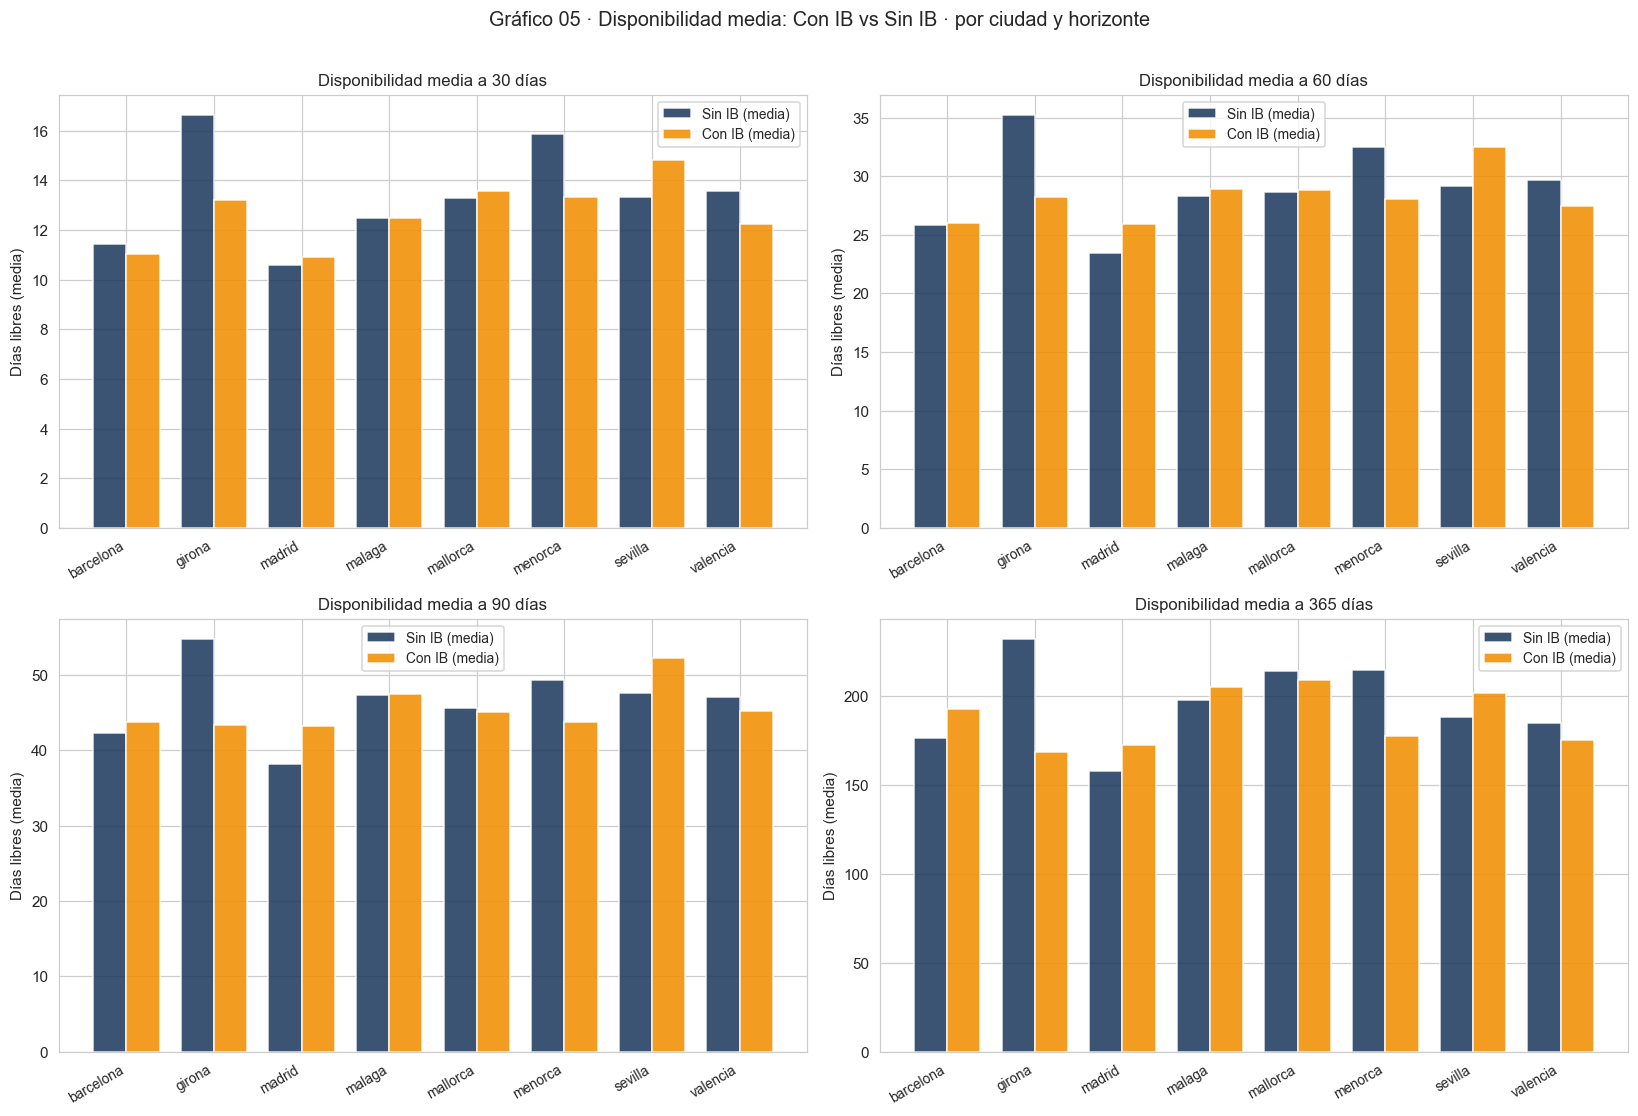

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (h, t) in enumerate(zip(horizontes, titulos)):
    ax = axes[i]
    imp = tabla_impacto(df, h).sort_index()
    x   = np.arange(len(imp))
    w   = 0.38
    ax.bar(x - w/2, imp['Media_Sin_IB'], w, label='Sin IB (media)', color=AZUL,    alpha=0.87)
    ax.bar(x + w/2, imp['Media_Con_IB'], w, label='Con IB (media)', color=NARANJA, alpha=0.87)
    ax.set_xticks(x)
    ax.set_xticklabels(imp.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Disponibilidad media a {t}', fontsize=11)
    ax.set_ylabel('Días libres (media)')
    ax.legend(fontsize=9)

plt.suptitle('Gráfico 05 · Disponibilidad media: Con IB vs Sin IB · por ciudad y horizonte',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig05_barras_agrupadas.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** El gráfico revela **tres comportamientos distintos**, no uno solo:

- **Ciudades donde Con IB (naranja) tiene menos disponibilidad** (barra naranja más baja): **Girona** es el caso más marcado (−20% a −27% según el horizonte), seguida de **Menorca** (−11% a −17%) y, de forma más leve, **Valencia** (−4% a −10%).
- **Ciudades donde Con IB tiene *más* disponibilidad** (barra naranja más alta): **Madrid** (+3% a +13%) y **Sevilla** (+7% a +11%); **Barcelona** se suma a 365 días (+9%).
- **Ciudades sin diferencia apreciable**: **Málaga** y **Mallorca**, donde las barras azul y naranja son casi idénticas en todos los horizontes.

A 30, 60 y 90 días las diferencias absolutas son pequeñas en casi todas las ciudades; a **365 días** se amplifican mecánicamente (el horizonte es 4-6× mayor), haciendo más visibles tanto las reducciones (Girona −63,5 días, Menorca −37 días) como los aumentos (Barcelona +16, Madrid +15, Sevilla +13,5 días).

> ⚠️ **Importante:** que una diferencia sea visible en el gráfico **no implica que sea estadísticamente significativa ni operativamente relevante**. La significancia y el tamaño del efecto se evalúan en la sección 07 (Mann-Whitney + Cliff's δ + bootstrap). Adelantando el resultado: de todas estas diferencias visuales, **solo la de Girona** resulta significativa *y* con un tamaño de efecto no despreciable de forma consistente en los cuatro horizontes.

**En términos de negocio.** El gráfico muestra que la dirección del efecto del Instant Booking **no es uniforme entre ciudades**: en unas parece reducir los días libres del calendario y en otras aumentarlos. Sin embargo, la mayoría de estas diferencias son pequeñas y, como se verá, atribuibles al ruido estadístico. La única ciudad donde el patrón se confirma como real y consistente es **Girona**, que se estudia en detalle en la sección 11.


### 06.3 Heatmap del impacto relativo del IB (%) por ciudad y horizonte

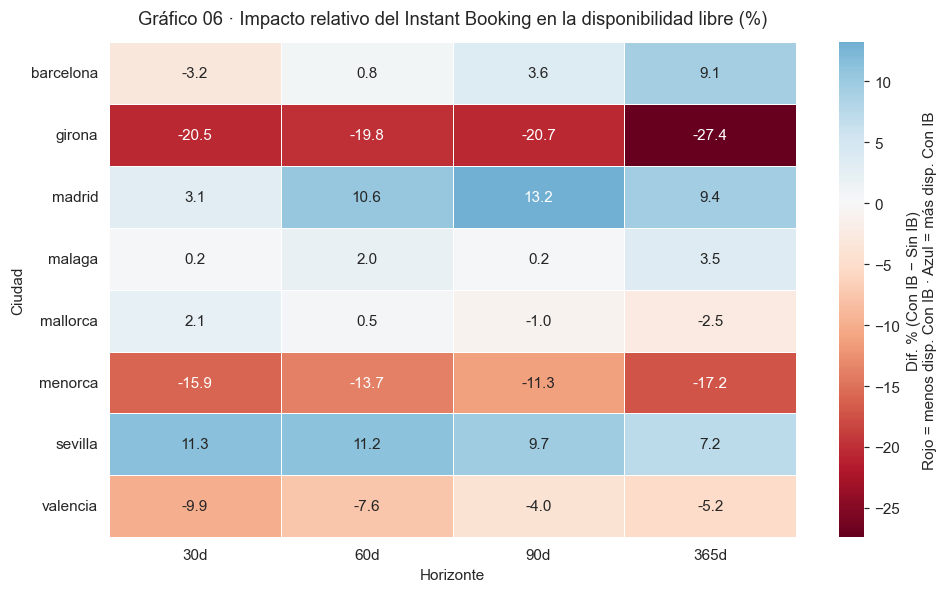


Cuadro 02 · Impacto relativo (%) del IB por ciudad y horizonte:


,30d,60d,90d,365d
city,,,,
barcelona,-3.20,0.80,3.60,9.10
girona,-20.50,-19.80,-20.70,-27.40
madrid,3.10,10.60,13.20,9.40
malaga,0.20,2.00,0.20,3.50
mallorca,2.10,0.50,-1.00,-2.50
menorca,-15.90,-13.70,-11.30,-17.20
sevilla,11.30,11.20,9.70,7.20
valencia,-9.90,-7.60,-4.00,-5.20


In [17]:
# ── Cuadro 02: Matriz de diferencia relativa (%) ──────────────────────────────
matriz_pct = pd.DataFrame()
for h in horizontes:
    imp = tabla_impacto(df, h)
    matriz_pct[h.replace('availability_', '')] = imp['Dif_media_pct']
matriz_pct.columns = ['30d', '60d', '90d', '365d']

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(matriz_pct, annot=True, fmt='.1f', cmap='RdBu', center=0,
            cbar_kws={'label': 'Dif. % (Con IB − Sin IB)\nRojo = menos disp. Con IB · Azul = más disp. Con IB'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Gráfico 06 · Impacto relativo del Instant Booking en la disponibilidad libre (%)',
             fontsize=12, pad=12)
ax.set_xlabel('Horizonte')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.savefig('fig06_heatmap_impacto_pct.png', bbox_inches='tight')
plt.show()
print("\nCuadro 02 · Impacto relativo (%) del IB por ciudad y horizonte:")
display(matriz_pct)

**Interpretación técnica.** El heatmap de impacto relativo es la visualización comparativa más informativa de esta sección. Con la escala de color empleada, los tonos **rojos** indican que los anuncios Con IB tienen *menos* días libres que los Sin IB (diferencia **negativa**); los **azules**, que tienen *más* días libres (diferencia **positiva**); los tonos neutros (cercanos al blanco), ausencia de impacto. Cuanto más intenso el color, mayor la magnitud (en valor absoluto).

- **Girona (rojo intenso en los 4 horizontes):** −20,5% (30d) a −27,4% (365d). Es el único mercado con un patrón negativo, fuerte y consistente en todos los horizontes — el rojo más oscuro del mapa.
- **Menorca (rojo moderado):** reducción consistente (−11% a −17%), pero su muestra pequeña obliga a tratar el dato con cautela (se confirma como no significativo en la sección 07).
- **Valencia (rojo claro):** reducción leve y decreciente (−9,9% a −4%); no significativa.
- **Madrid y Sevilla (azules):** patrón **opuesto** — los anuncios Con IB tienen *más* días libres (Madrid +3% a +13%, Sevilla +7% a +11%). Madrid resulta estadísticamente significativo, pero con un tamaño de efecto despreciable (ver 07.3 y 07.4).
- **Barcelona:** pasa de rojo muy leve a 30d (−3,2%) a azul a 365d (+9,1%); el signo no es estable a lo largo del horizonte.
- **Málaga y Mallorca (casi blancos):** valores próximos a 0% — el IB no altera la disponibilidad.

**En términos de negocio.** El mapa de calor permite ver de un vistazo que el efecto del Instant Booking **no apunta en la misma dirección en todas las ciudades**: reduce los días libres (rojo) en Girona, Menorca y Valencia, pero los aumenta ligeramente (azul) en Madrid y Sevilla. La mayoría de estos colores corresponden a diferencias pequeñas que el análisis estadístico de la sección 07 descarta como ruido. La excepción robusta sigue siendo **Girona**, donde el rojo intenso refleja un efecto real: sus anfitriones con reserva automática muestran consistentemente menos días libres, lo que sugiere una gestión más activa del calendario.


## 07 · Significancia estadística y tamaño del efecto

Las diferencias observadas en §06 pueden ser reales o deberse al azar. En este bloque verificamos cuáles son estadísticamente significativas y, sobre todo, cuáles tienen relevancia práctica para el negocio.

### 07.1 ¿Por qué Mann-Whitney y no el test t?

**Técnicamente:** las distribuciones de disponibilidad no son normales (lo confirmamos en §03). Presentan picos en 0 y en el máximo, con forma asimétrica. El test t de Student asume normalidad y es sensible a outliers. **Mann-Whitney U** trabaja con rangos —no asume ninguna forma distribucional— y es robusto frente a los anuncios con calendarios extremos.

**En términos sencillos:** el test t compara promedios y se puede "engañar" cuando hay muchos valores extremos. Mann-Whitney es más honesto con datos como estos, porque no le importa si hay anuncios con el calendario completamente libre o completamente bloqueado; compara los grupos sin que esos casos distorsionen el resultado.

### 07.2 ¿Por qué Cliff's delta?

**Técnicamente:** con 7.693 anuncios, Mann-Whitney puede declarar diferencias **estadísticamente significativas** que en la práctica son irrelevantes (ej.: 0,3 días de diferencia con p < 0,01). Cliff's delta mide la probabilidad de que un anuncio Con IB tenga más disponibilidad que uno Sin IB, y va de −1 a +1:

| |delta| | Magnitud del efecto |
|---|---|
| < 0,15 | Despreciable (sin relevancia operativa) |
| 0,15 – 0,33 | Pequeño |
| 0,33 – 0,47 | Mediano |
| ≥ 0,47 | Grande |

**En términos sencillos:** cuando trabajamos con miles de anuncios, casi cualquier diferencia —incluso una de 0,3 días— puede aparecer como "significativa" estadísticamente. Por eso necesitamos una segunda medida que nos diga si esa diferencia importa en la práctica. Cliff's delta hace exactamente eso: nos dice si la diferencia es real y relevante, o simplemente detectable por el gran tamaño de la muestra.

### 07.3 Intervalos de confianza bootstrap

**Técnicamente:** en lugar de los IC clásicos (que asumen normalidad), se usa bootstrap: se remuestrean los datos empíricamente 2.000 veces y se construye el IC al 95% a partir de los propios datos, sin supuestos distribucionales.

**En términos sencillos:** los intervalos de confianza nos dicen el rango dentro del cual probablemente se mueve la diferencia real entre grupos. Si ese rango incluye el valor 0, significa que no podemos descartar que no haya diferencia. El método bootstrap calcula esos rangos directamente a partir de los datos, sin necesitar asumir que siguen una distribución normal.

In [18]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────
def cliffs_delta(x, y):
    """Cliff's delta = (P(X>Y) - P(X<Y)) entre los dos grupos."""
    nx, ny = len(x), len(y)
    count = sum(1 if xi > yi else -1 if xi < yi else 0
                for xi in x for yi in y)
    return count / (nx * ny)

def bootstrap_ci(x, y, n_boot=2000, seed=42):
    """IC al 95% bootstrap para la diferencia de medias (x - y)."""
    rng = np.random.default_rng(seed)
    diffs = [rng.choice(x, len(x), replace=True).mean() -
             rng.choice(y, len(y), replace=True).mean()
             for _ in range(n_boot)]
    return tuple(np.percentile(diffs, [2.5, 97.5]))

def interp_delta(d):
    a = abs(d)
    if   a < 0.15: return 'despreciable'
    elif a < 0.33: return 'pequeño'
    elif a < 0.47: return 'mediano'
    else:          return 'grande'

print("Funciones definidas: cliffs_delta, bootstrap_ci, interp_delta ✓")

Funciones definidas: cliffs_delta, bootstrap_ci, interp_delta ✓


In [19]:
# ── Análisis completo: Mann-Whitney + Cliff's delta + Bootstrap · 4 horizontes ─
resultados = []

for h in horizontes:
    for ciudad in sorted(df['city'].unique()):
        sub = df[df['city'] == ciudad]
        con = sub[sub['is_instant_bookable'] == True][h].dropna().values
        sin = sub[sub['is_instant_bookable'] == False][h].dropna().values

        stat, pval = mannwhitneyu(con, sin, alternative='two-sided')
        cd  = cliffs_delta(con, sin)
        ci  = bootstrap_ci(con, sin)
        dif = con.mean() - sin.mean()
        dif_pct = dif / sin.mean() * 100

        resultados.append({
            'horizonte'   : h,
            'ciudad'      : ciudad,
            'n_con'       : len(con),
            'n_sin'       : len(sin),
            'media_con'   : round(con.mean(), 2),
            'media_sin'   : round(sin.mean(), 2),
            'mediana_con' : round(np.median(con), 1),
            'mediana_sin' : round(np.median(sin), 1),
            'dif_dias'    : round(dif, 2),
            'dif_pct'     : round(dif_pct, 1),
            'p_value'     : round(pval, 4),
            'sig'         : pval < 0.05,
            'cliffs_d'    : round(cd, 3),
            'magnitud'    : interp_delta(cd),
            'ci_95_low'   : round(ci[0], 2),
            'ci_95_high'  : round(ci[1], 2),
        })

df_res = pd.DataFrame(resultados)
print(f"Combinaciones analizadas: {len(df_res)} (8 ciudades × 4 horizontes)")

Combinaciones analizadas: 32 (8 ciudades × 4 horizontes)


In [20]:
# ── Cuadro 03: Resumen enfocado en availability_30 ────────────────────────────
res_30 = df_res[df_res['horizonte'] == 'availability_30'].set_index('ciudad')

cols_mostrar = ['n_con','n_sin','media_con','media_sin','mediana_con','mediana_sin',
                'dif_dias','dif_pct','p_value','sig','cliffs_d','magnitud',
                'ci_95_low','ci_95_high']
print("Cuadro 03 · Resultados completos para availability_30:")
display(res_30[cols_mostrar])

Cuadro 03 · Resultados completos para availability_30:


,n_con,n_sin,media_con,media_sin,mediana_con,mediana_sin,dif_dias,dif_pct,p_value,sig,cliffs_d,magnitud,ci_95_low,ci_95_high
ciudad,,,,,,,,,,,,,,
barcelona,1057,1204,11.05,11.42,8.00,7.00,-0.36,-3.20,0.41,False,0.02,despreciable,-1.30,0.56
girona,711,487,13.22,16.62,11.00,22.00,-3.40,-20.50,0.00,True,-0.13,despreciable,-4.90,-1.98
madrid,917,728,10.91,10.57,9.00,5.00,0.33,3.20,0.01,True,0.07,despreciable,-0.75,1.39
malaga,274,120,12.48,12.47,11.00,10.00,0.02,0.10,0.67,False,0.03,despreciable,-2.31,2.48
mallorca,756,509,13.58,13.30,12.00,12.00,0.28,2.10,0.55,False,0.02,despreciable,-1.09,1.64
menorca,89,78,13.34,15.87,9.00,23.00,-2.53,-16.00,0.51,False,-0.06,despreciable,-6.54,1.46
sevilla,274,129,14.83,13.32,14.00,10.00,1.51,11.30,0.13,False,0.09,despreciable,-0.87,3.81
valencia,181,179,12.24,13.58,9.00,14.00,-1.34,-9.90,0.55,False,-0.04,despreciable,-3.84,1.07


**Interpretación técnica (availability_30).**

- **Girona:** diferencia estadísticamente significativa (p < 0,001) con tamaño del efecto en el límite *pequeño-despreciable* (|δ| = 0,132). Los anuncios Con IB tienen **3,4 días menos disponibles** en el próximo mes (−20,5%). La mediana confirma la señal: 11 días (Con IB) vs 22 días (Sin IB).
- **Madrid:** **también es estadísticamente significativo** (p = 0,011), pero con |δ| = 0,072 (despreciable). La diferencia es de apenas +0,3 días: detectable por el gran tamaño muestral, **pero sin ninguna relevancia operativa**.
- **Resto de ciudades (Barcelona, Málaga, Mallorca, Menorca, Sevilla, Valencia):** p > 0,05 y |δ| < 0,10 — diferencias dentro del ruido estadístico.

> **Matiz importante:** a 30 días hay **dos** ciudades con p < 0,05 (Girona y Madrid), no una sola. La diferencia entre ambas no está en el p-value sino en el **tamaño del efecto**: solo Girona combina significancia con una magnitud relevante. Este es precisamente el motivo por el que el p-value, por sí solo, no basta para decidir.

**En términos de negocio.** El caso de Madrid ilustra la trampa del p-value: con miles de anuncios, es fácil detectar diferencias minúsculas (0,3 días) que son estadísticamente "reales" pero prácticamente irrelevantes. Por eso usamos Cliff's δ como segundo filtro: si el efecto es despreciable, la diferencia no merece atención operativa, **independientemente del p-value**. Aplicando ambos criterios, solo Girona representa un efecto accionable.


In [21]:
# ── Cuadro 04: Tabla consolidada todos los horizontes ──────────────────
pivot_p     = df_res.pivot_table(index='ciudad', columns='horizonte', values='p_value',  aggfunc='first')
pivot_delta = df_res.pivot_table(index='ciudad', columns='horizonte', values='cliffs_d', aggfunc='first')
pivot_dif   = df_res.pivot_table(index='ciudad', columns='horizonte', values='dif_dias', aggfunc='first')

# Reordenar columnas por horizonte temporal
orden_cols = ['availability_30', 'availability_60', 'availability_90', 'availability_365']
nombres    = ['30d', '60d', '90d', '365d']
pivot_p     = pivot_p[orden_cols].rename(columns=dict(zip(orden_cols, nombres)))
pivot_delta = pivot_delta[orden_cols].rename(columns=dict(zip(orden_cols, nombres)))
pivot_dif   = pivot_dif[orden_cols].rename(columns=dict(zip(orden_cols, nombres)))

# ── Cuadro 04a · p-value con RESALTADO de p < 0,05 ─────────────────────────
def resalta_sig(val):
    """Fondo amarillo + negrita roja si p < 0,05 (significativo)."""
    if val < 0.05:
        return 'background-color: #FFE08A; color: #B00020; font-weight: bold;'
    return 'color: #6B7280;'

print("Cuadro 04a · p-value por horizonte  (resaltado = p < 0,05, estadísticamente significativo):")
sty = (pivot_p.round(4).style
       .map(resalta_sig)
       .format('{:.4f}')
       .set_caption('p-value Mann-Whitney U · Con IB vs Sin IB'))
display(sty)

print("\nCuadro 04b · Cliff's delta por horizonte (signo = dirección; |δ| ≥ 0,15 = efecto no despreciable):")
def resalta_delta(val):
    a = abs(val)
    if   a >= 0.15: return 'background-color: #FFCDA8; font-weight: bold;'  # efecto relevante
    else:           return 'color: #9CA3AF;'                                 # despreciable
sty_d = (pivot_delta.round(3).style
         .map(resalta_delta)
         .format('{:+.3f}')
         .set_caption("Cliff's δ  (resaltado = |δ| ≥ 0,15)"))
display(sty_d)

print("\nCuadro 04c · Diferencia de medias Con IB − Sin IB (días):")
display(pivot_dif.round(2))

# Resumen textual: ¿qué ciudades son significativas Y con efecto relevante?
print("\n" + "="*70)
print("  Síntesis: significancia (p<0,05) vs. tamaño del efecto (|δ|≥0,15)")
print("="*70)
for ciudad in pivot_p.index:
    sig_h   = [h for h in nombres if pivot_p.loc[ciudad, h] < 0.05]
    efec_h  = [h for h in nombres if abs(pivot_delta.loc[ciudad, h]) >= 0.15]
    ambos   = [h for h in nombres if pivot_p.loc[ciudad, h] < 0.05 and abs(pivot_delta.loc[ciudad, h]) >= 0.15]
    if ambos:
        print(f"  ✔ {ciudad.capitalize():11s} → SIGNIFICATIVO + EFECTO RELEVANTE en: {', '.join(ambos)}")
    elif sig_h:
        print(f"    {ciudad.capitalize():11s} → significativo (p<0,05) en {sig_h} pero |δ| despreciable")
    else:
        print(f"    {ciudad.capitalize():11s} → sin significancia en ningún horizonte")


Cuadro 04a · p-value por horizonte  (resaltado = p < 0,05, estadísticamente significativo):


horizonte,30d,60d,90d,365d
ciudad,,,,
barcelona,0.4092,0.4992,0.4390,0.0257
girona,0.0001,0.0000,0.0000,0.0000
madrid,0.0109,0.0039,0.0057,0.0278
malaga,0.6703,0.7509,0.8492,0.8205
mallorca,0.5517,0.8045,0.9207,0.3144
menorca,0.5053,0.6758,0.7044,0.0855
sevilla,0.1273,0.1597,0.3364,0.4748
valencia,0.5518,0.5040,0.6416,0.5324



Cuadro 04b · Cliff's delta por horizonte (signo = dirección; |δ| ≥ 0,15 = efecto no despreciable):


horizonte,30d,60d,90d,365d
ciudad,,,,
barcelona,+0.020,+0.016,+0.019,+0.054
girona,-0.132,-0.166,-0.193,-0.282
madrid,+0.072,+0.082,+0.079,+0.063
malaga,+0.027,+0.020,-0.012,+0.014
mallorca,+0.020,+0.008,-0.003,-0.033
menorca,-0.058,-0.037,-0.034,-0.155
sevilla,+0.094,+0.087,+0.059,+0.044
valencia,-0.036,-0.041,-0.028,-0.038



Cuadro 04c · Diferencia de medias Con IB − Sin IB (días):


horizonte,30d,60d,90d,365d
ciudad,,,,
barcelona,-0.36,0.21,1.53,15.99
girona,-3.40,-6.97,-11.33,-63.51
madrid,0.33,2.48,5.03,14.85
malaga,0.02,0.57,0.08,6.91
mallorca,0.28,0.14,-0.47,-5.39
menorca,-2.53,-4.44,-5.58,-36.95
sevilla,1.51,3.28,4.60,13.50
valencia,-1.34,-2.25,-1.87,-9.59



  Síntesis: significancia (p<0,05) vs. tamaño del efecto (|δ|≥0,15)
    Barcelona   → significativo (p<0,05) en ['365d'] pero |δ| despreciable
  ✔ Girona      → SIGNIFICATIVO + EFECTO RELEVANTE en: 60d, 90d, 365d
    Madrid      → significativo (p<0,05) en ['30d', '60d', '90d', '365d'] pero |δ| despreciable
    Malaga      → sin significancia en ningún horizonte
    Mallorca    → sin significancia en ningún horizonte
    Menorca     → sin significancia en ningún horizonte
    Sevilla     → sin significancia en ningún horizonte
    Valencia    → sin significancia en ningún horizonte


### 07.4 Visualización: Cliff's delta por ciudad y horizonte

C:\Users\vanem\AppData\Local\Temp\ipykernel_10760\2768048722.py:25: UserWarning: Glyph 10022 (\N{BLACK FOUR POINTED STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vanem\AppData\Local\Temp\ipykernel_10760\2768048722.py:26: UserWarning: Glyph 10022 (\N{BLACK FOUR POINTED STAR}) missing from font(s) Arial.
  plt.savefig('fig07_cliffs_delta.png', bbox_inches='tight')
C:\Users\vanem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10022 (\N{BLACK FOUR POINTED STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


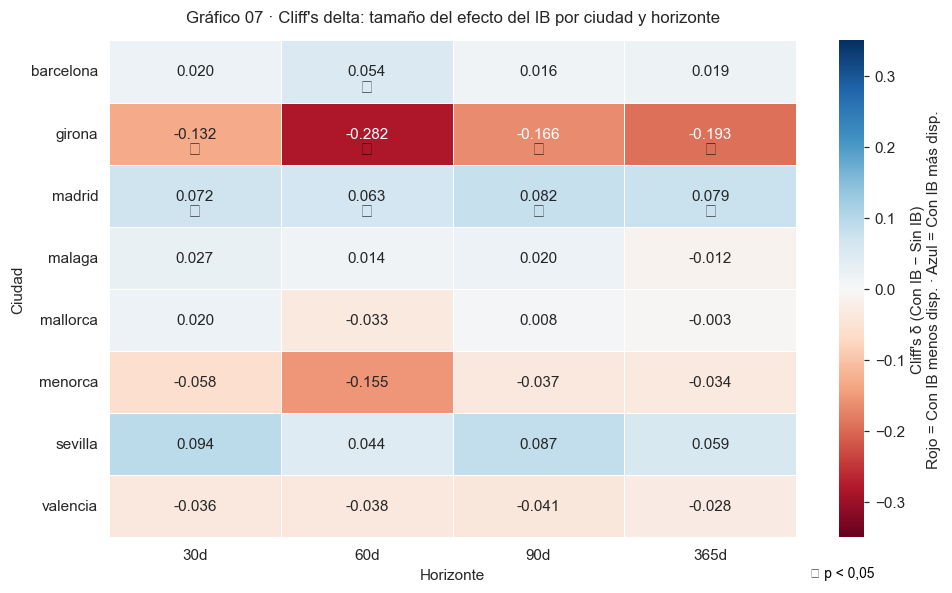

In [22]:
# ── Gráfico 07: Heatmap Cliff's delta ────────────────────────────────────────
delta_matrix = df_res.pivot(index='ciudad', columns='horizonte', values='cliffs_d')
delta_matrix.columns = ['30d','60d','90d','365d']

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(delta_matrix, annot=True, fmt='.3f', cmap='RdBu', center=0,
            vmin=-0.35, vmax=0.35,
            cbar_kws={'label': "Cliff's δ (Con IB − Sin IB)\nRojo = Con IB menos disp. · Azul = Con IB más disp."},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title("Gráfico 07 · Cliff's delta: tamaño del efecto del IB por ciudad y horizonte",
             fontsize=11, pad=12)
ax.set_xlabel('Horizonte')
ax.set_ylabel('Ciudad')

# Añadir asterisco en celdas significativas (p < 0.05)
sig_matrix = df_res.pivot(index='ciudad', columns='horizonte', values='sig')
sig_matrix.columns = ['30d','60d','90d','365d']
for y_idx, ciudad in enumerate(delta_matrix.index):
    for x_idx, h in enumerate(delta_matrix.columns):
        if sig_matrix.loc[ciudad, h]:
            ax.text(x_idx + 0.5, y_idx + 0.75, '✦',
                    ha='center', va='center', fontsize=12, color='black')

ax.text(1.02, -0.08, '✦ p < 0,05', transform=ax.transAxes, fontsize=9, color='black')
plt.tight_layout()
plt.savefig('fig07_cliffs_delta.png', bbox_inches='tight')
plt.show()

**Cómo leer el gráfico.** Cada celda es el **Cliff's δ** de esa ciudad y horizonte, que mide el tamaño del efecto del IB sobre la disponibilidad. El valor y el color se interpretan así:

- **Signo del número** = dirección: δ **negativo** → Con IB tiene *menos* disponibilidad; δ **positivo** → Con IB tiene *más*.
- **Color** (misma convención que el gráfico 06): **rojo** = δ negativo (Con IB menos disp.), **azul** = δ positivo (Con IB más disp.), blanco = sin efecto.
- **Magnitud** = cuánto se aleja de 0 (en cualquier dirección). Umbrales prácticos: |δ| < 0,15 *despreciable*, 0,15–0,33 *pequeño*, 0,33–0,47 *mediano*, > 0,47 *grande*. La escala se ha fijado entre −0,35 y +0,35 para que los matices sean visibles.
- **✦** = diferencia estadísticamente significativa (p < 0,05).

> Nota sobre la etiqueta de la barra de color ("Con IB − Sin IB"): indica simplemente que el δ se calcula como el grupo Con IB *frente al* grupo Sin IB. Un valor de −1 significaría que Con IB **siempre** tiene menos disponibilidad que Sin IB; +1, lo contrario; 0, indistinguible. Ninguna ciudad se acerca a esos extremos: el δ más fuerte es Girona a 365d (−0,282), todavía en rango *pequeño*.

**Lectura por ciudad:**
- **Girona (rojo, ✦ en los 4 horizontes):** único mercado que supera el umbral *despreciable* a partir de 60 días (δ = −0,166 a 60d, −0,193 a 365d → efecto *pequeño* real y creciente). A 30d (δ = −0,132) queda justo por debajo del umbral, pero ya es significativo.
- **Menorca (rojo, sin ✦):** δ negativo que llega a −0,155 a 60d (efecto *pequeño*), pero **no significativo** (p > 0,05), probablemente por su muestra reducida.
- **Madrid y Barcelona (azul muy claro, ✦ a 365d):** el ✦ indica que la diferencia es estadísticamente detectable, pero el δ (≈0,06–0,08) es *despreciable*: irrelevante en la práctica pese al asterisco.
- **Resto (Málaga, Mallorca, Sevilla, Valencia):** δ < 0,10 en valor absoluto y sin ✦ — el IB no tiene efecto apreciable.

**En términos de negocio.** Este mapa es el más completo para decidir: combina si el efecto es **real** (✦) y si es **importante** (cuánto se aleja del centro). Solo **Girona** reúne ambas condiciones. El resto, aunque algunas celdas tengan ✦, presentan diferencias tan pequeñas que no justifican ninguna acción operativa.

**Conclusión del bloque estadístico:** Solo en **Girona** el Instant Booking tiene un efecto estadísticamente significativo *y* operativamente relevante (efecto *pequeño*), que además crece con el horizonte temporal.


## 08 · Distribución completa por ciudad: boxplots Con IB vs Sin IB

Los boxplots muestran la **distribución completa** de disponibilidad, no solo la media. Permiten detectar si la diferencia entre grupos refleja un desplazamiento de toda la distribución o solo de unos pocos valores extremos.

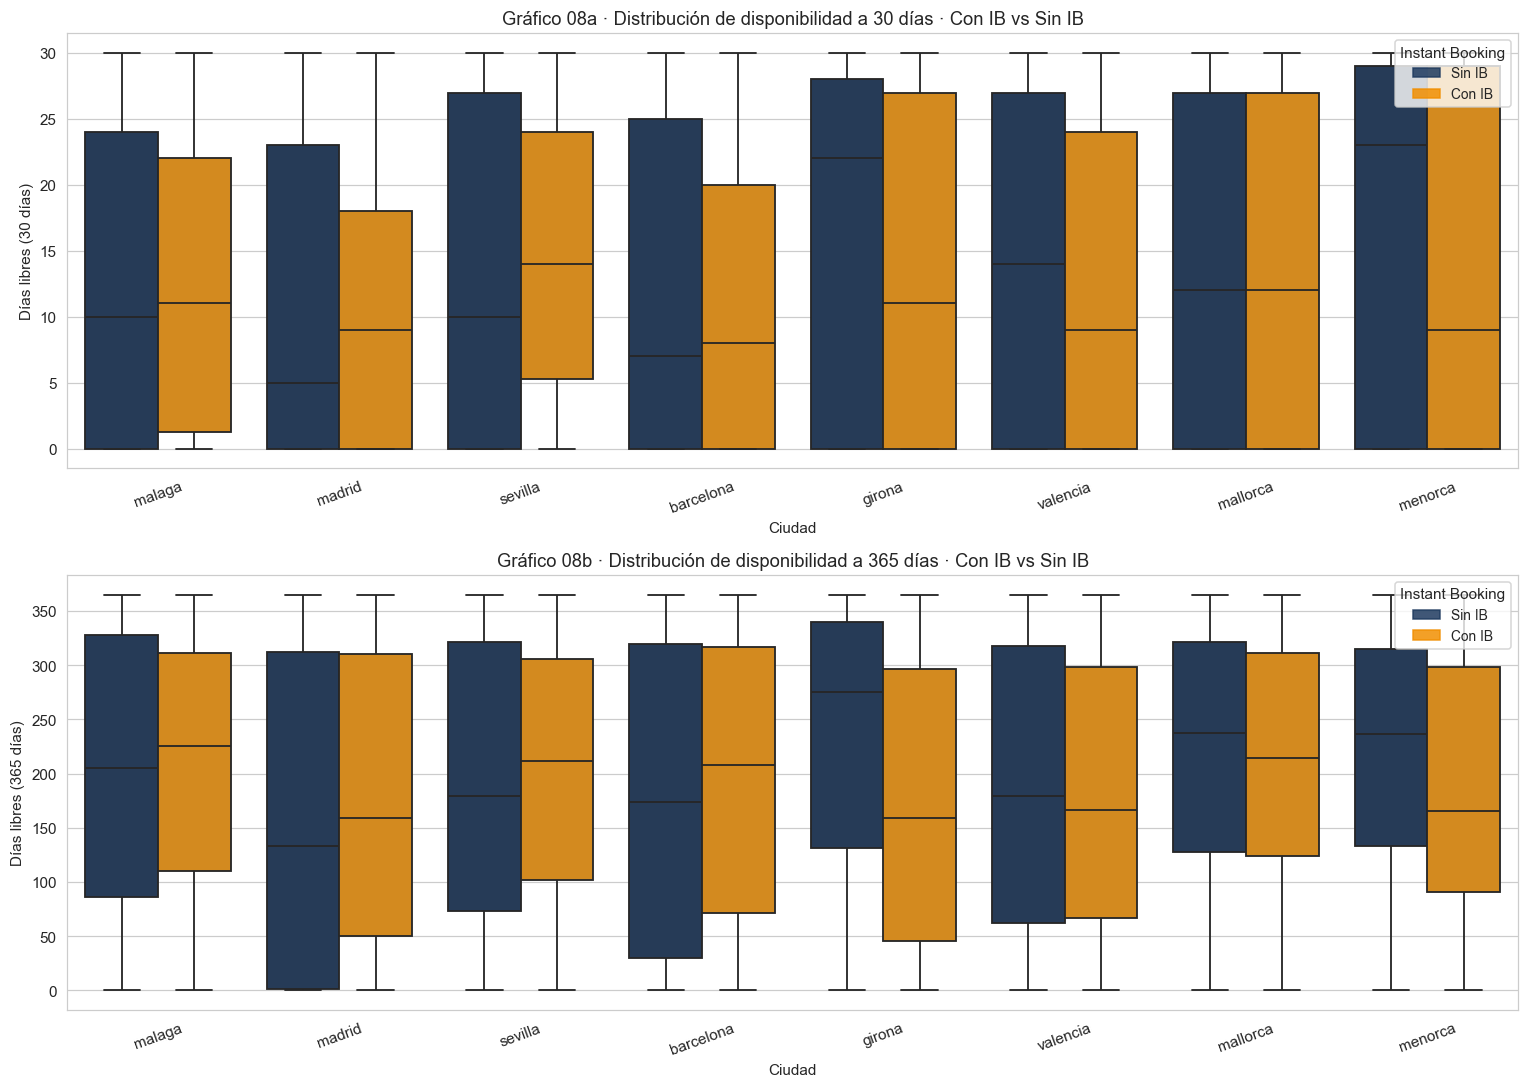

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

patch_sin = mpatches.Patch(color=AZUL,    alpha=0.85, label='Sin IB')
patch_con = mpatches.Patch(color=NARANJA, alpha=0.85, label='Con IB')

for idx, (h, t) in enumerate(zip(['availability_30', 'availability_365'],
                                  ['30 días', '365 días'])):
    ax = axes[idx]
    sns.boxplot(data=df, x='city', y=h, hue='is_instant_bookable',
                palette={True: NARANJA, False: AZUL},
                ax=ax, fliersize=2, linewidth=1.2)
    ax.set_title(f'Gráfico 08{"a" if idx==0 else "b"} · Distribución de disponibilidad a {t} · Con IB vs Sin IB',
                 fontsize=12)
    ax.set_xlabel('Ciudad', fontsize=10)
    ax.set_ylabel(f'Días libres ({t})')
    ax.legend(handles=[patch_sin, patch_con], title='Instant Booking',
              loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig08_boxplots.png', bbox_inches='tight')
plt.show()

**Cómo leer el gráfico.** Cada par de cajas (azul = **Sin IB**, naranja = **Con IB**) se dibuja una al lado de la otra para cada ciudad. La línea horizontal dentro de la caja es la **mediana**; los bordes de la caja son el primer y tercer cuartil (el 50% central de los anuncios); los bigotes llegan a los valores extremos. Para comparar los dos grupos hay que fijarse sobre todo en **la altura de la mediana** y en si una caja está desplazada verticalmente respecto a la otra.

**A 30 días.** En la mayoría de ciudades, las dos cajas cubren franjas verticales muy parecidas (cuartiles casi idénticos) y sus medianas están próximas: Málaga (10 vs 11), Barcelona (7 vs 8) y Mallorca (12 vs 12) son los casos más claros de **igualdad** entre grupos. Las excepciones son:
- **Girona:** la mediana Sin IB es 22 días y la Con IB cae a 11 — la línea naranja queda netamente más abajo.
- **Menorca:** salto aún mayor en la mediana (23 → 9), aunque las cajas son muy altas y los bigotes amplios, lo que diluye la diferencia (de ahí su falta de significancia).
- **Valencia** muestra un descenso más leve (14 → 9) y **Madrid/Sevilla** un ligero ascenso de la mediana Con IB.

**A 365 días.** Las cajas son muy altas en todas las ciudades (gran dispersión anual) y, salvo excepciones, se sitúan en rangos parecidos. Lo relevante vuelve a ser la mediana:
- **Girona:** descenso muy marcado, mediana Sin IB ≈ 275 días frente a Con IB ≈ 159 — toda la caja naranja se desplaza hacia abajo. Es el efecto más visible del gráfico.
- **Menorca:** patrón similar (236 → 165), pero no significativo.
- **Madrid, Barcelona y Sevilla:** la mediana Con IB queda algo *por encima* de la Sin IB (p. ej. Barcelona 174 → 208). En Madrid y Barcelona esa diferencia es estadísticamente significativa, pero su tamaño de efecto es despreciable (Cliff's δ < 0,07): las cajas ocupan prácticamente el mismo rango y la diferencia carece de relevancia operativa.

**Asimetría.** En casi todas las ciudades las distribuciones tienen colas largas (bigotes desiguales), lo que justifica el uso de Mann-Whitney (no paramétrico) en lugar del test t.

**En términos de negocio.** Los boxplots confirman visualmente que el efecto en **Girona** es real y afecta a toda la cartera de la ciudad — la mediana baja con claridad, no por unos pocos anuncios atípicos. En el resto de ciudades los dos grupos ocupan rangos prácticamente iguales; los desplazamientos de mediana visibles a un lado u otro (incluidos los significativos de Madrid y Barcelona a 365d) son pequeños y, como confirma la sección 07 vía Cliff's δ, no son operativamente relevantes.


## 09 · Control metodológico: estratificación por room_type

**¿Por qué es necesario este paso?** Los anuncios Con IB tienen una composición diferente por tipo de alojamiento que los Sin IB: el grupo Con IB tiene un 76% de `Entire home/apt` vs. un 64% en el grupo Sin IB. Si en una ciudad los anuncios Con IB son mayoritariamente pisos completos y los Sin IB son mayoritariamente habitaciones privadas, la diferencia de disponibilidad observada podría deberse al **tipo de alojamiento** y no al IB.

**En términos sencillos:** estamos asegurándonos de comparar «manzanas con manzanas». Si no controlamos por tipo de alojamiento, podríamos estar comparando pisos completos (Con IB) contra habitaciones privadas (Sin IB), y la diferencia en días libres podría venir del tipo de alojamiento, no de la reserva automática. Para descartarlo, repetimos el análisis comparando solo pisos completos entre sí, y solo habitaciones privadas entre sí.

In [24]:
# ── Cuadro 05: Composición de room_type por grupo IB ─────────────────────────
comp = df.groupby(['is_instant_bookable','room_type']).size().unstack(fill_value=0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
comp_pct.index = ['Sin IB', 'Con IB']
comp_pct = comp_pct.round(1)
print("Cuadro 05 · Composición de room_type dentro de cada grupo (%):")
display(comp_pct.T)
print("\nNota: Hotel room (1,2%) y Shared room (0,6-0,7%) son categorías marginales.")
print("El control se realiza sobre Entire home/apt y Private room, que representan el 98% del dataset.")

Cuadro 05 · Composición de room_type dentro de cada grupo (%):


,Sin IB,Con IB
room_type,,
Entire home/apt,64.10,76.30
Hotel room,0.00,1.20
Private room,35.10,21.90
Shared room,0.70,0.60



Nota: Hotel room (1,2%) y Shared room (0,6-0,7%) son categorías marginales.
El control se realiza sobre Entire home/apt y Private room, que representan el 98% del dataset.


In [25]:
# ── Estratificación: Entire home/apt y Private room ───────────────────────────
df_entire  = df[df['room_type'] == 'Entire home/apt'].copy()
df_private = df[df['room_type'] == 'Private room'].copy()

print(f"Submuestra Entire home/apt : {len(df_entire):,} anuncios ({len(df_entire)/len(df)*100:.1f}% del total)")
print(f"Submuestra Private room    : {len(df_private):,} anuncios ({len(df_private)/len(df)*100:.1f}% del total)")

# Tabla comparativa: global vs. Entire vs. Private (availability_30)
comp_comparativa = []

for ciudad in sorted(df['city'].unique()):
    # Global
    sub_g = df[df['city']==ciudad]
    con_g = sub_g[sub_g['is_instant_bookable']==True]['availability_30'].dropna().values
    sin_g = sub_g[sub_g['is_instant_bookable']==False]['availability_30'].dropna().values
    stat_g, p_g = mannwhitneyu(con_g, sin_g, alternative='two-sided')
    cd_g = cliffs_delta(con_g, sin_g)

    row = {
        'ciudad'       : ciudad,
        'dif_global_%' : round((con_g.mean()-sin_g.mean())/sin_g.mean()*100, 1),
        'p_global'     : round(p_g, 4),
        'delta_global' : round(cd_g, 3),
    }

    # Entire home/apt
    sub_e = df_entire[df_entire['city']==ciudad]
    con_e = sub_e[sub_e['is_instant_bookable']==True]['availability_30'].dropna().values
    sin_e = sub_e[sub_e['is_instant_bookable']==False]['availability_30'].dropna().values
    if len(con_e) >= 10 and len(sin_e) >= 10:
        stat_e, p_e = mannwhitneyu(con_e, sin_e, alternative='two-sided')
        cd_e = cliffs_delta(con_e, sin_e)
        row.update({'dif_entire_%': round((con_e.mean()-sin_e.mean())/sin_e.mean()*100, 1),
                    'p_entire': round(p_e, 4), 'delta_entire': round(cd_e, 3),
                    'n_con_entire': len(con_e), 'n_sin_entire': len(sin_e)})
    else:
        row.update({'dif_entire_%': None, 'p_entire': None, 'delta_entire': None,
                    'n_con_entire': len(con_e), 'n_sin_entire': len(sin_e)})

    # Private room
    sub_p = df_private[df_private['city']==ciudad]
    con_p = sub_p[sub_p['is_instant_bookable']==True]['availability_30'].dropna().values
    sin_p = sub_p[sub_p['is_instant_bookable']==False]['availability_30'].dropna().values
    if len(con_p) >= 10 and len(sin_p) >= 10:
        stat_p, p_p = mannwhitneyu(con_p, sin_p, alternative='two-sided')
        cd_p = cliffs_delta(con_p, sin_p)
        row.update({'dif_private_%': round((con_p.mean()-sin_p.mean())/sin_p.mean()*100, 1),
                    'p_private': round(p_p, 4), 'delta_private': round(cd_p, 3),
                    'n_con_private': len(con_p), 'n_sin_private': len(sin_p)})
    else:
        row.update({'dif_private_%': None, 'p_private': None, 'delta_private': None,
                    'n_con_private': len(con_p), 'n_sin_private': len(sin_p)})

    comp_comparativa.append(row)

df_comp = pd.DataFrame(comp_comparativa).set_index('ciudad')
print("\nCuadro 06 · Comparación global vs. Entire home/apt vs. Private room — availability_30:")
display(df_comp)

Submuestra Entire home/apt : 5,453 anuncios (70.9% del total)
Submuestra Private room    : 2,138 anuncios (27.8% del total)

Cuadro 06 · Comparación global vs. Entire home/apt vs. Private room — availability_30:


,dif_global_%,p_global,delta_global,dif_entire_%,p_entire,delta_entire,n_con_entire,n_sin_entire,dif_private_%,p_private,delta_private,n_con_private,n_sin_private
ciudad,,,,,,,,,,,,,
barcelona,-3.20,0.41,0.02,5.20,0.03,0.08,563,498,-11.00,0.29,-0.04,473,694
girona,-20.50,0.00,-0.13,-19.30,0.00,-0.12,670,458,-29.90,0.11,-0.23,35,29
madrid,3.20,0.01,0.07,5.60,0.03,0.08,653,398,-5.80,0.69,0.02,246,319
malaga,0.10,0.67,0.03,6.60,0.38,0.06,235,89,-24.00,0.41,-0.12,33,31
mallorca,2.10,0.55,0.02,2.90,0.47,0.03,688,465,-4.40,0.74,-0.04,56,43
menorca,-16.00,0.51,-0.06,-18.00,0.41,-0.07,81,75,NaN,NaN,NaN,8,3
sevilla,11.30,0.13,0.09,5.20,0.52,0.05,221,88,10.60,0.37,0.11,44,40
valencia,-9.90,0.55,-0.04,-8.60,0.65,-0.03,140,131,-11.20,0.95,-0.01,36,48


**Interpretación técnica.** La comparación entre las columnas *global*, *Entire home/apt* y *Private room* es el test de robustez clave del análisis:

- **Girona — Entire home/apt:** la diferencia se mantiene casi idéntica (−20,5% global vs −19,3% Entire) y sigue siendo significativa (p < 0,01). El efecto del IB en Girona **no es un artefacto de composición** del inventario: existe dentro del segmento de apartamentos completos.
- **Girona — Private room:** la diferencia es mayor en términos relativos (−29,9%), pero no alcanza significancia estadística (p = 0,106) por el reducido número de habitaciones privadas en Girona (n=64). La dirección del efecto es consistente, aunque no concluyente.
- **Madrid y Barcelona:** al filtrar por Entire, las diferencias se vuelven ligeramente positivas. Esto sugiere que en el análisis global parte de la señal provenía de la mezcla de tipos de alojamiento.
- **Resto de ciudades:** sin cambios relevantes — la señal era nula antes y sigue siendo nula.

**En términos de negocio.** El resultado de Girona es robusto: comparando solo pisos completos entre sí, los que tienen reserva automática siguen teniendo menos días libres. No es un efecto ilusorio producido por comparar tipos diferentes de alojamiento. En el resto de ciudades, el resultado sigue siendo el mismo: la reserva automática no cambia la disponibilidad.

## 10 · Intervalos de confianza bootstrap

Los IC bootstrap cuantifican la **incertidumbre** de las diferencias de medias observadas. Un IC que incluye el 0 indica que la diferencia podría ser cero con un 95% de confianza — el resultado es inconcluyente. Se muestran para `availability_30` y `availability_365`, los horizontes operativamente más relevantes.

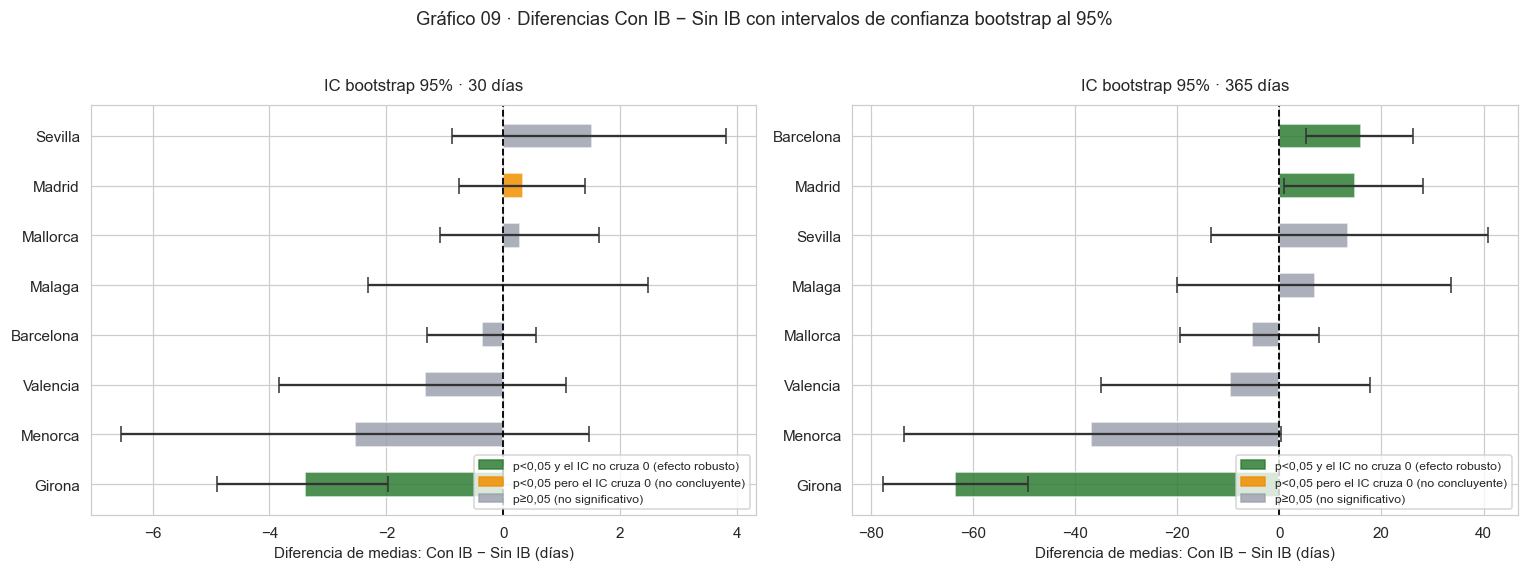

In [26]:
# ── Gráfico 09: IC bootstrap por ciudad ──────────────────────────────
# Codificación de color CORREGIDA para evitar ambigüedad:
#   - VERDE  : significativo (p<0,05) Y el IC bootstrap NO cruza el 0  → efecto robusto
#   - NARANJA: significativo en Mann-Whitney pero el IC bootstrap SÍ cruza el 0 → no concluyente
#   - GRIS   : no significativo (p≥0,05)
# El color ya NO depende del lado del cero, sino de la solidez del efecto.

VERDE = '#2E7D32'
GRIS  = '#9CA3AF'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, h, t in zip(axes,
                    ['availability_30', 'availability_365'],
                    ['30 días', '365 días']):
    sub_res = df_res[df_res['horizonte'] == h].copy().sort_values('dif_dias')
    ciudades = sub_res['ciudad'].values
    difs     = sub_res['dif_dias'].values
    ci_low   = sub_res['ci_95_low'].values
    ci_high  = sub_res['ci_95_high'].values
    pvals    = sub_res['p_value'].values

    colores = []
    for p, lo, hi in zip(pvals, ci_low, ci_high):
        cruza_cero = (lo <= 0 <= hi)
        if p < 0.05 and not cruza_cero:
            colores.append(VERDE)      # efecto robusto
        elif p < 0.05 and cruza_cero:
            colores.append(NARANJA)    # significativo pero IC cruza 0
        else:
            colores.append(GRIS)       # no significativo
    y = np.arange(len(ciudades))

    ax.barh(y, difs, color=colores, alpha=0.85, height=0.5)
    ax.errorbar(difs, y,
                xerr=[difs - ci_low, ci_high - difs],
                fmt='none', color='#333', capsize=5, lw=1.5)
    ax.axvline(0, color='black', lw=1.2, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels([c.capitalize() for c in ciudades], fontsize=10)
    ax.set_xlabel('Diferencia de medias: Con IB − Sin IB (días)', fontsize=10)
    ax.set_title(f'IC bootstrap 95% · {t}', fontsize=11, pad=10)

    p_verde  = mpatches.Patch(color=VERDE,   alpha=0.85, label='p<0,05 y el IC no cruza 0 (efecto robusto)')
    p_naranja= mpatches.Patch(color=NARANJA, alpha=0.85, label='p<0,05 pero el IC cruza 0 (no concluyente)')
    p_gris   = mpatches.Patch(color=GRIS,    alpha=0.85, label='p≥0,05 (no significativo)')
    ax.legend(handles=[p_verde, p_naranja, p_gris], fontsize=8, loc='lower right')

plt.suptitle('Gráfico 09 · Diferencias Con IB − Sin IB con intervalos de confianza bootstrap al 95%',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('fig09_bootstrap_ci.png', bbox_inches='tight')
plt.show()


**Cómo leer este gráfico.** Cada barra es la diferencia de medias estimada (Con IB − Sin IB) y el bigote negro es su intervalo de confianza bootstrap al 95%. La regla clave: **si el bigote cruza la línea discontinua del 0, no podemos descartar que el efecto real sea nulo**. El color resume la conclusión combinando significancia y robustez:

- 🟩 **Verde** = significativo (p<0,05) **y** el IC no toca el 0 → la diferencia es real con 95% de confianza.
- 🟧 **Naranja** = significativo en Mann-Whitney **pero** el IC de la media cruza el 0 → resultado no concluyente.
- ⬜ **Gris** = no significativo (p≥0,05).

> **Por qué veías barras del mismo color a izquierda y derecha del cero en la versión anterior:** el color marcaba únicamente la *significancia* (p<0,05), **no la dirección** del efecto. La **posición** de la barra (izquierda/derecha del 0) es la que indica el signo: a la **izquierda** = Con IB tiene *menos* días libres; a la **derecha** = *más* días libres. Como había ciudades significativas en ambos sentidos (p. ej. Girona a la izquierda y Madrid a la derecha), aparecían barras del mismo color a ambos lados del cero, lo que resultaba confuso. La nueva codificación separa esos casos: el color ahora distingue si el efecto es **robusto** (verde) o solo aparente (naranja/gris), y el lado sigue indicando la dirección.

**Lectura por ciudad:**
- **Girona** (verde, a la izquierda en ambos paneles): a 30d el IC es [−4,9 ; −1,98] y a 365d [−77,7 ; −49,1]. En ambos casos todo el intervalo está por debajo del 0 → efecto real, consistente y de gran magnitud absoluta a 365 días (−63,5 días de media).
- **Madrid a 30 días** (naranja): aunque Mann-Whitney da p<0,05, el IC bootstrap de la media [−0,75 ; +1,39] **cruza el 0** → no concluyente. La diferencia real es de apenas +0,3 días.
- **Madrid y Barcelona a 365 días** (verde, a la derecha): aquí sus IC **no** cruzan el 0 (Madrid [+0,95 ; +28], Barcelona [+5,2 ; +26]) → estadísticamente significativos. **Pero ojo:** su tamaño de efecto (Cliff's δ) sigue siendo *despreciable* (|δ|<0,07, ver Cuadro 04b). Es el mismo fenómeno de Madrid a 30d pero a mayor horizonte: con miles de anuncios, una diferencia relativa pequeña (+9%) se vuelve detectable sin ser operativamente relevante. **No deben interpretarse como un efecto accionable.**
- **Resto** (gris): IC que cruzan el 0 — diferencias no concluyentes (incluida Menorca, cuyo IC a 365d roza el 0: [−73,4 ; +0,4]).

**En términos de negocio.** Este es el gráfico más honesto del análisis: muestra la diferencia estimada **y** su margen de incertidumbre. El bootstrap por sí solo confirma significancia en Girona, Madrid y Barcelona, pero combinado con el tamaño del efecto (sección 07) **solo Girona** representa un impacto real y accionable: todo su intervalo a la izquierda del 0 y con magnitud relevante. Los casos verdes de Madrid y Barcelona a 365d son significativos pero triviales en términos prácticos — un recordatorio de que significancia ≠ relevancia.


## 11 · Análisis detallado de Girona

Girona merece un análisis específico por ser el único mercado con efecto relevante y estadísticamente significativo en todos los horizontes. Este zoom nos permitirá entender mejor la naturaleza del efecto y formular hipótesis operativas.

In [27]:
# ── Girona: estadísticas detalladas ──────────────────────────────────────────
girona     = df[df['city'] == 'girona'].copy()
girona_con = girona[girona['is_instant_bookable'] == True]
girona_sin = girona[girona['is_instant_bookable'] == False]

print("=== GIRONA: comparación detallada ===\n")
print(f"Anuncios Con IB: {len(girona_con):,}  ({len(girona_con)/len(girona)*100:.1f}% de Girona)")
print(f"Anuncios Sin IB: {len(girona_sin):,}  ({len(girona_sin)/len(girona)*100:.1f}% de Girona)\n")

stats_girona = []
for h in horizontes:
    con_v = girona_con[h].dropna().values
    sin_v = girona_sin[h].dropna().values
    stat, pval = mannwhitneyu(con_v, sin_v, alternative='two-sided')
    cd  = cliffs_delta(con_v, sin_v)
    ci  = bootstrap_ci(con_v, sin_v)
    stats_girona.append({
        'horizonte'   : h,
        'media_Con'   : round(con_v.mean(), 1),
        'media_Sin'   : round(sin_v.mean(), 1),
        'mediana_Con' : round(np.median(con_v), 1),
        'mediana_Sin' : round(np.median(sin_v), 1),
        'dif_dias'    : round(con_v.mean()-sin_v.mean(), 1),
        'dif_pct'     : round((con_v.mean()-sin_v.mean())/sin_v.mean()*100, 1),
        'p_value'     : round(pval, 4),
        'cliff_delta' : round(cd, 3),
        'magnitud'    : interp_delta(cd),
        'CI_low'      : round(ci[0], 1),
        'CI_high'     : round(ci[1], 1),
    })

df_girona = pd.DataFrame(stats_girona).set_index('horizonte')
print("Cuadro 07 · Girona: resultados por horizonte")
display(df_girona)

=== GIRONA: comparación detallada ===

Anuncios Con IB: 711  (59.3% de Girona)
Anuncios Sin IB: 487  (40.7% de Girona)

Cuadro 07 · Girona: resultados por horizonte


,media_Con,media_Sin,mediana_Con,mediana_Sin,dif_dias,dif_pct,p_value,cliff_delta,magnitud,CI_low,CI_high
horizonte,,,,,,,,,,,
availability_30,13.20,16.60,11.00,22.00,-3.40,-20.50,0.00,-0.13,despreciable,-4.90,-2.00
availability_60,28.20,35.20,29.00,44.00,-7.00,-19.80,0.00,-0.17,pequeño,-9.80,-4.30
availability_90,43.40,54.70,48.00,66.00,-11.30,-20.70,0.00,-0.19,pequeño,-15.30,-7.40
availability_365,168.20,231.70,159.00,275.00,-63.50,-27.40,0.00,-0.28,pequeño,-77.60,-49.10


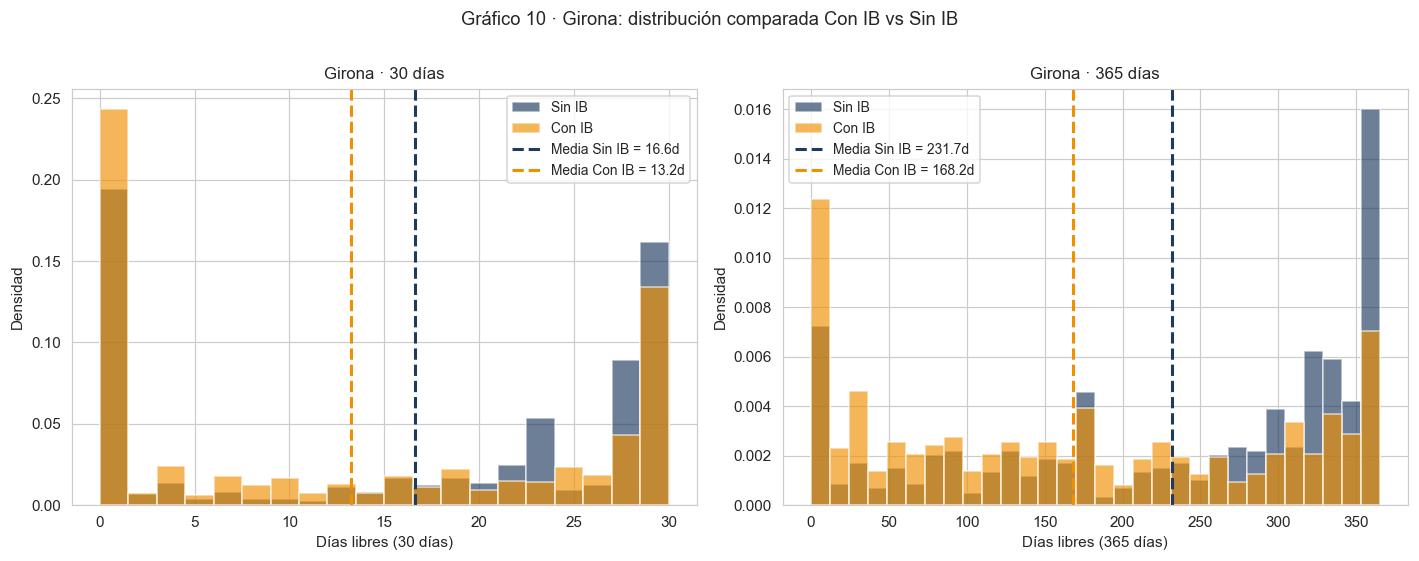

In [28]:
# ── Gráfico 10: Girona histograma comparativo ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, h, t in zip(axes, ['availability_30','availability_365'], ['30 días','365 días']):
    bins = 20 if h == 'availability_30' else 30
    ax.hist(girona_sin[h], bins=bins, color=AZUL,    alpha=0.65, label='Sin IB', density=True)
    ax.hist(girona_con[h], bins=bins, color=NARANJA, alpha=0.65, label='Con IB', density=True)
    ax.axvline(girona_sin[h].mean(), color=AZUL,    lw=2, linestyle='--',
               label=f'Media Sin IB = {girona_sin[h].mean():.1f}d')
    ax.axvline(girona_con[h].mean(), color=NARANJA, lw=2, linestyle='--',
               label=f'Media Con IB = {girona_con[h].mean():.1f}d')
    ax.set_title(f'Girona · {t}', fontsize=11)
    ax.set_xlabel(f'Días libres ({t})', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Gráfico 10 · Girona: distribución comparada Con IB vs Sin IB', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig10_girona_detalle.png', bbox_inches='tight')
plt.show()

**Interpretación técnica.** Los histogramas muestran la distribución de densidad de días libres para cada grupo.

- **A 30 días:** los anuncios Sin IB tienen un pico pronunciado en valores altos (mediana 22 días libres), mientras los Con IB se desplazan hacia la izquierda (mediana 11 días). El desplazamiento afecta a toda la distribución, no solo a la media.
- **A 365 días:** la diferencia es aún más marcada. Los Sin IB se concentran en valores muy altos (mediana ≈ 275 días — anuncios con el año prácticamente libre), mientras los Con IB se distribuyen en valores intermedios (mediana ≈ 159 días). El Cliff's delta de −0,282 a 365 días (efecto *pequeño*) refleja este desplazamiento consistente.

**En términos de negocio.** Los anuncios con reserva automática en Girona se parecen entre sí: tienen calendarios más gestionados, con menos días libres. Los anuncios sin reserva automática son más heterogéneos: algunos también gestionan activamente su calendario, pero hay una proporción importante con el calendario prácticamente abierto durante todo el año, lo que sugiere que son propietarios ocasionales que no han bloqueado fechas ni confirmado reservas.

**Lectura operativa para Girona:** En Girona, el IB lo usan principalmente anfitriones *profesionales* con alta rotación, que mantienen el calendario actualizado y tienen muchos días reservados o bloqueados. Los anfitriones Sin IB en Girona incluyen una proporción mayor de propietarios *ocasionales* que no gestionan activamente sus fechas, dejando el calendario artificialmente "abierto". Esta diferencia de perfil de anfitrión es lo que explica la brecha de disponibilidad, más que el propio efecto del IB en sí.

## 12 · Conclusiones y respuesta a la pregunta de negocio

---

### 12.1 Respuesta directa a la pregunta

> *¿Quin impacte té l'opció de reservar automàticament en la disponibilitat mitjana a cada ciutat?*

**Salvo en Girona, la opción de reserva automática no tiene un impacto relevante en la disponibilidad media: en la mayoría de ciudades las diferencias entre anuncios con y sin Instant Booking son menores de 2 días y operativamente despreciables. Solo en Girona los anuncios con IB muestran consistentemente menos días libres, y ese efecto es estadísticamente significativo y se mantiene al controlar por tipo de alojamiento.**

Este patrón se observa en el heatmap de impacto relativo **(gráfico 06)** y en el heatmap de Cliff's delta **(gráfico 07)**. La robustez del efecto en Girona se confirma con los intervalos de confianza bootstrap **(gráfico 09)**, el análisis detallado **(cuadro 07, gráfico 10)** y el control por tipo de alojamiento **(cuadro 06)**.

---

### 12.2 Resumen ejecutivo por ciudad

In [29]:
# ── Cuadro 08: Tabla resumen ejecutivo ───────────────────────────────────────
resumen = []
for ciudad in sorted(df['city'].unique()):
    sub    = df_res[(df_res['ciudad'] == ciudad) & (df_res['horizonte'] == 'availability_30')]
    sub365 = df_res[(df_res['ciudad'] == ciudad) & (df_res['horizonte'] == 'availability_365')]
    resumen.append({
        'Ciudad'          : ciudad.capitalize(),
        'n_Con_IB'        : sub['n_con'].values[0],
        'n_Sin_IB'        : sub['n_sin'].values[0],
        'Adopción IB'     : f"{sub['n_con'].values[0]/(sub['n_con'].values[0]+sub['n_sin'].values[0])*100:.0f}%",
        'Dif 30d (días)'  : f"{sub['dif_dias'].values[0]:+.1f}",
        'p-value 30d'     : sub['p_value'].values[0],
        "Cliff's δ 30d"   : sub['cliffs_d'].values[0],
        'Dif 365d (días)' : f"{sub365['dif_dias'].values[0]:+.1f}",
        'p-value 365d'    : sub365['p_value'].values[0],
        "Cliff's δ 365d"  : sub365['cliffs_d'].values[0],
        'Veredicto'       : ('⚠️ Efecto real (pequeño)'
                             if ciudad == 'girona' else
                             '⚠️ Muestra pequeña — no concluyente' if ciudad == 'menorca' else
                             '✓ Sin efecto relevante'),
    })

df_resumen = pd.DataFrame(resumen).set_index('Ciudad')
print("Cuadro 08 · Resumen ejecutivo por ciudad")
display(df_resumen)

Cuadro 08 · Resumen ejecutivo por ciudad


,n_Con_IB,n_Sin_IB,Adopción IB,Dif 30d (días),p-value 30d,Cliff's δ 30d,Dif 365d (días),p-value 365d,Cliff's δ 365d,Veredicto
Ciudad,,,,,,,,,,
Barcelona,1057,1204,47%,-0.4,0.41,0.02,+16.0,0.03,0.05,✓ Sin efecto relevante
Girona,711,487,59%,-3.4,0.00,-0.13,-63.5,0.00,-0.28,⚠️ Efecto real (pequeño)
Madrid,917,728,56%,+0.3,0.01,0.07,+14.8,0.03,0.06,✓ Sin efecto relevante
Malaga,274,120,70%,+0.0,0.67,0.03,+6.9,0.82,0.01,✓ Sin efecto relevante
Mallorca,756,509,60%,+0.3,0.55,0.02,-5.4,0.31,-0.03,✓ Sin efecto relevante
Menorca,89,78,53%,-2.5,0.51,-0.06,-37.0,0.09,-0.15,⚠️ Muestra pequeña — no concluyente
Sevilla,274,129,68%,+1.5,0.13,0.09,+13.5,0.47,0.04,✓ Sin efecto relevante
Valencia,181,179,50%,-1.3,0.55,-0.04,-9.6,0.53,-0.04,✓ Sin efecto relevante


---

### 12.3 Hallazgos clave

**1. Girona: el único mercado con efecto real** *(cuadros 03, 04, 07 · gráficos 06, 07, 09, 10)*

Los anuncios con Instant Booking activado tienen **−3,4 días menos disponibles a 30 días** (−20,5%) y **−63,5 días menos a 365 días** (−27,4%) respecto a los Sin IB. Este efecto:
- Es estadísticamente significativo en todos los horizontes (p < 0,001) **(cuadro 03, cuadro 04)**.
- Se mantiene al controlar por room_type: dentro de `Entire home/apt` la diferencia es casi idéntica (−19,3%), y la dirección es consistente también en `Private room` aunque sin alcanzar significancia estadística por el reducido tamaño muestral **(cuadro 06)**.
- Crece con el horizonte — no es una anomalía puntual sino un patrón estructural **(cuadro 04c)**.
- Tiene un Cliff's delta que sube de despreciable a *pequeño* en horizontes largos **(gráfico 07)**.
- El IC bootstrap no incluye el 0 en ningún horizonte **(gráfico 09)**.

**2. El resto de ciudades: sin efecto relevante** *(cuadro 08 · gráficos 05, 06, 07)*

En Barcelona, Madrid, Málaga, Mallorca, Sevilla y Valencia, las diferencias entre Con IB y Sin IB son menores de 2 días a 30 días **(cuadro 04c)**. Aunque algunos p-values son < 0,05 (Madrid en todos los horizontes; Barcelona a 365d) e incluso algún IC bootstrap no llega a tocar el 0 (Madrid y Barcelona a 365d), los **Cliff's delta son despreciables** (< 0,10) en todos los casos **(gráfico 07)**. Es decir: la diferencia es detectable pero su magnitud es trivial — un artefacto del gran tamaño muestral. **Conclusión práctica: el Instant Booking no cambia apreciablemente la disponibilidad en estos mercados.**

**3. Menorca: señal ruidosa — no concluyente** *(cuadros 03, 08)*

La diferencia observada (−2,5 días a 30d, −16% relativo) es llamativa, pero con solo 167 anuncios en total no se puede descartar que sea variabilidad aleatoria (p > 0,05 en todos los horizontes). Con una muestra tan pequeña, los intervalos de confianza son amplios y los resultados no son concluyentes.

**4. Hallazgo contraintuitivo en Madrid (y Barcelona)** *(cuadros 03, 04 · gráficos 06, 09)*

Los anuncios Con IB en Madrid tienen ligeramente *más* disponibilidad que los Sin IB (+3,2% a 30d, +9,4% a 365d) **(cuadro 04c)** — el patrón opuesto al de Girona. Estas diferencias son **estadísticamente significativas** (p < 0,05 en los cuatro horizontes para Madrid; a 365d el IC bootstrap tampoco incluye el 0 ni para Madrid ni para Barcelona, **gráfico 09**), pero su **tamaño de efecto es despreciable** (Cliff's δ < 0,08): la diferencia es real pero tan pequeña que no tiene relevancia operativa. Es el ejemplo de manual de *significancia sin importancia práctica* que motiva el uso de Cliff's δ. La dirección positiva podría sugerir que en Madrid y Barcelona el IB lo activan también anfitriones con inventario menos gestionado, aunque el dato no justifica ninguna acción.

**5. A nivel de plataforma: el IB no es un determinante de la disponibilidad** *(cuadro 08)*

El efecto real se concentra exclusivamente en Girona, que representa el 15,6% del inventario total (1.198 de 7.693 anuncios). Para el 84,4% restante de la cartera, la decisión de activar o no el IB no está asociada a diferencias operativas en la disponibilidad visible.

---

### 12.4 Limitaciones metodológicas

| Limitación | Impacto en las conclusiones |
|---|---|
| Dataset estático (fotografía puntual) | No distingue entre días "reservados" y días "bloqueados voluntariamente"; disponibilidad ≠ ocupación real |
| Sin datos longitudinales | No podemos observar el mismo anuncio antes y después de activar el IB |
| Factor de selección | Los anfitriones que activan el IB pueden ser más profesionales por razones independientes al IB |
| Muestras pequeñas | Menorca (n=167) tiene resultados con mayor incertidumbre |
| Variables confusoras no controladas | Reputación del anfitrión, estacionalidad y precio no están controlados |

> **El análisis es correlacional, no causal.** No podemos afirmar que activar el Instant Booking *cause* menor disponibilidad. Para establecer causalidad se requeriría un experimento A/B o datos longitudinales (historial antes/después de activar el IB en los mismos anuncios).

---

### 12.5 Recomendaciones operativas

**1. Girona — monitorear la brecha de disponibilidad** *(cuadro 07 · gráfico 10)*
Es el único mercado donde el IB se asocia a una diferencia operativa real. Si la plataforma quiere aumentar la disponibilidad visible de anuncios Con IB en Girona, puede plantearse incentivar a esos anfitriones a abrir más fechas. Si, por el contrario, la menor disponibilidad refleja mayor ocupación real, puede ser una señal positiva de rendimiento que conviene rastrear.

**2. Barcelona y Madrid — buscar otras palancas** *(cuadro 08 · gráfico 06)*
El IB no es un factor determinante de la disponibilidad en estos mercados **(cuadro 03)**. Los esfuerzos para mejorar la disponibilidad visible deben dirigirse a otras variables: política de precios, incentivos de gestión del calendario o captación de nuevo inventario.

**3. Menorca — ampliar la muestra antes de decidir** *(cuadro 03)*
Con n=167, los datos no son concluyentes. No se recomienda tomar decisiones operativas sobre este mercado basándose en los resultados actuales.

**4. Análisis futuro — datos longitudinales**
Para responder la pregunta de negocio de forma causal (¿activar el IB *causa* cambios en la disponibilidad?) sería necesario disponer del historial de reservas y evolución del calendario de los mismos anuncios antes y después de activar el IB, o diseñar un experimento A/B controlado.

### Propuestas priorizadas para la Directora (foco: Operaciones e Inventario)

| # | Propuesta | Hallazgo que la justifica | Prioridad | Recursos necesarios |
|---|---|---|---|---|
| 1 | **No condicionar la política de IB a la disponibilidad** | En 7 de 8 ciudades el IB es ruido estadítico. La decisión operativa sobre su uso debe basarse en la conversión y la experiencia del cliente (CX), no en una falsa premisa de getsión de inventario. | **Alta** | Operaciones + Producto|
| 2 | **Monitorear Girona como caso atípico** | Es el único mercado con señal real. Investigar a fondo el perfil del anfitrión gerundense; si la menor disponibilidad refleja mayor ocupación real, es un patrón de alto rendimiento que conviene replicar. | **Media** | Operaciones + datos |
| 3 | **Activar al propietario ocasional** | Existe un volumen oculto de inventario con calendarios abiertos todo el año sin gestionar. Implementar campañas de acompañamiento para liberar disponibilidad útil | **Media** | Comercial + Atención al anfitrión|